# Trabalho Prático 2 - Extração de Conhecimento de Dados de Espetroscopia Raman
## Grupo 7

**Compostos atribuídos:**
1,3-Dimethyl-2-imidazolidinone | 2-Propanol | 2,2-Dimethoxypropane | 4-Methyl-2-pentanone | Acetic acid | Acetone | Acetonitrile | Benzaldehyde | Benzyl bromide | Butyl acetate

---

### Descrição dos compostos

| Composto | Fórmula | Família Química | Papel |
|---|---|---|---|
| 1,3-Dimethyl-2-imidazolidinone (1,3-DMI) | C5H10N2O | Ureia cíclica / amida | Solvente polar aprótico, intermediário |
| 2-Propanol | C3H8O | Álcool secundário | Solvente, desinfetante |
| 2,2-Dimethoxypropane (2,2-DMP) | C5H12O2 | Acetal | Agente secante, intermediário |
| 4-Methyl-2-pentanone (MIBK) | C6H12O | Cetona | Solvente industrial |
| Acetic acid | CH3COOH | Ácido carboxilico | Reagente, solvente |
| Acetone | C3H6O | Cetona | Solvente universal |
| Acetonitrile | C2H3N | Nitrilo | Solvente HPLC |
| Benzaldehyde | C7H6O | Aldeído aromático | Reagente, perfumaria |
| Benzyl bromide | C7H7Br | Haleto benzílico | Agente de alquilação |
| Butyl acetate | C6H12O2 | Ester | Solvente, indústria alimentar |

A diversidade de famílias químicas - álcoois, cetonas, ácidos, esteres, nitrilos, aromáticos e heterocíclicos - torna o conjunto simultaneamente rico para a exploração espetral e exigente do ponto de vista da classificação.


## 1. Importação de bibliotecas e carregamento dos dados

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter, find_peaks
from scipy.interpolate import interp1d
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                              classification_report, confusion_matrix,
                              accuracy_score)
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                     train_test_split, learning_curve)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import umap.umap_ as umap_
from pybaselines import Baseline
import shap

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
palette = sns.color_palette('tab10', 10)
SEED = 42
np.random.seed(SEED)

print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


In [4]:
# Carregamento do dataset completo
df_all = pd.read_csv('raman_data.csv')

# Compostos do Grupo 7
GROUP7 = [
    '1,3-Dimethyl-2-imidazolidinone',
    '2 - Propanol',
    '2, 2 - Dimethoxy Propane',
    '4-Methyl-2-pentanone',
    'Acetic acid',
    'Acetone',
    'Acetonitrile',
    'Benzaldehyde',
    'Benzyl bromide',
    'Butyl Acetate',
]

LABEL_MAP = {
    '1,3-Dimethyl-2-imidazolidinone': '1,3-DMI',
    '2 - Propanol':                   '2-Propanol',
    '2, 2 - Dimethoxy Propane':       '2,2-DMP',
    '4-Methyl-2-pentanone':           'MIBK',
    'Acetic acid':                    'Acetic acid',
    'Acetone':                        'Acetone',
    'Acetonitrile':                   'Acetonitrile',
    'Benzaldehyde':                   'Benzaldehyde',
    'Benzyl bromide':                 'Benzyl bromide',
    'Butyl Acetate':                  'Butyl acetate',
}

df = df_all[df_all['label'].isin(GROUP7)].copy()
df['compound'] = df['label'].map(LABEL_MAP)

wavenumbers = df.columns[:-2].astype(float).values
X_raw = df.iloc[:, :-2].values
y_str = df['compound'].values
compounds = list(LABEL_MAP.values())

print(f'Dataset Grupo 7')
print(f'  Espectros    : {X_raw.shape[0]}')
print(f'  Raman shifts : {X_raw.shape[1]}')
print(f'  Gama         : {wavenumbers.min():.1f} - {wavenumbers.max():.1f} cm-1')
print()
print('Distribuição por composto:')
print(df['compound'].value_counts().to_string())


Dataset Grupo 7
  Espectros    : 1101
  Raman shifts : 3276
  Gama         : 150.0 - 3425.0 cm-1

Distribuição por composto:
compound
Benzaldehyde      121
Acetone           120
Acetic acid       113
Benzyl bromide    112
1,3-DMI           109
2-Propanol        109
2,2-DMP           107
Butyl acetate     106
Acetonitrile      104
MIBK              100


## 2. Pré-processamento

Valores em falta: 0
Pre-processamento concluido:
  OK Verificacao de valores em falta
  OK Suavizacao Savitzky-Golay (janela=11, ordem=3)
  OK Correccao de baseline — rubber-band (referencia) e ALS (lam=1e6, p=0.001)
  OK Normalizacao: min-max e SNV (Standard Normal Variate)


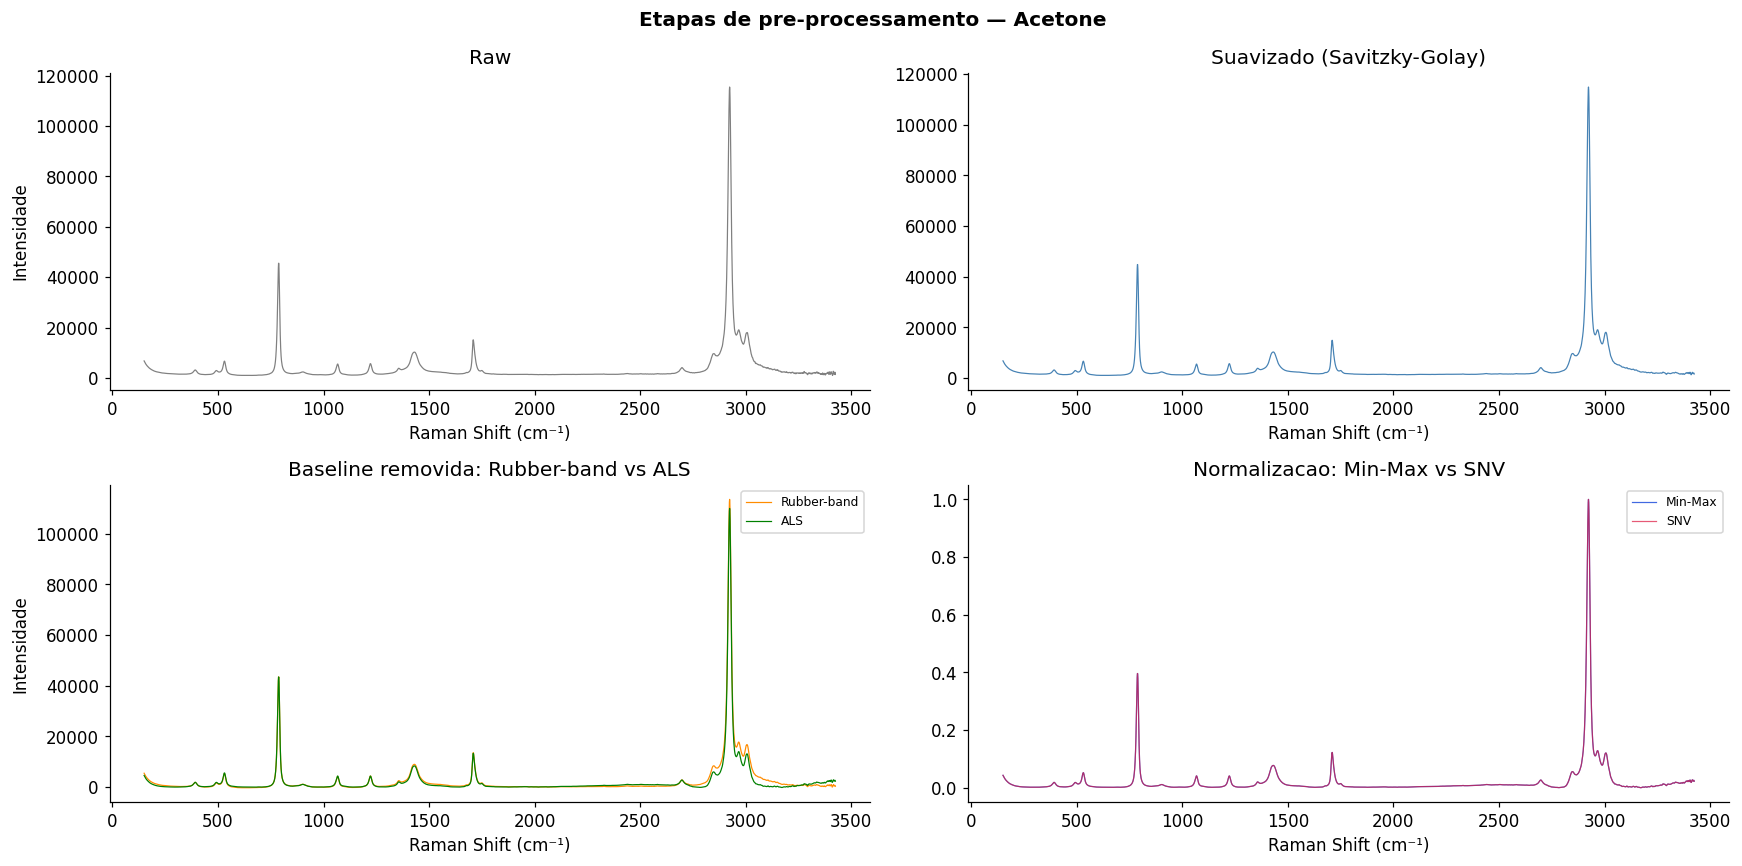

In [5]:

# 2.1  Valores em falta

missing = np.isnan(X_raw).sum()
print(f'Valores em falta: {missing}')
if missing > 0:
    df_feat = pd.DataFrame(X_raw, columns=wavenumbers)
    df_feat.interpolate(axis=1, inplace=True)
    X_raw = df_feat.values


# 2.2  Suavização Savitzky-Golay

X_smooth = savgol_filter(X_raw, window_length=11, polyorder=3, axis=1)


# 2.3a  Correcção de baseline — rubber-band (original, para comparação)

def rubberband_baseline(spectrum, wavenumbers):
    n = len(wavenumbers)
    w = max(1, n // 10)
    idx_left  = np.argmin(spectrum[:w])
    idx_right = n - 1 - np.argmin(spectrum[n-w:][::-1])
    pts_x = [wavenumbers[idx_left],  wavenumbers[idx_right]]
    pts_y = [spectrum[idx_left],     spectrum[idx_right]]
    fn = interp1d(pts_x, pts_y, fill_value='extrapolate')
    return fn(wavenumbers)

X_bc_rb = np.zeros_like(X_smooth)
for i, spec in enumerate(X_smooth):
    bl = rubberband_baseline(spec, wavenumbers)
    X_bc_rb[i] = spec - bl


# 2.3b  Correção de baseline — ALS (Asymmetric Least Squares) mais robusta para espetros com fluorescência curva

baseline_fitter = Baseline(x_data=wavenumbers)
X_bc = np.zeros_like(X_smooth)
for i, spec in enumerate(X_smooth):
    bkg, _ = baseline_fitter.asls(spec, lam=1e6, p=0.001)
    X_bc[i] = spec - bkg


# 2.4a  Normalização min-max por espetro (0-1)  [baseline = rubber-band]

X_min = X_bc.min(axis=1, keepdims=True)
X_max = X_bc.max(axis=1, keepdims=True)
X_norm = (X_bc - X_min) / (X_max - X_min + 1e-10)


# 2.4b  SNV — Standard Normal Variate (alternativa mais comum em espetroscopia; robusta a scatter e variações de intensidade)

X_snv = (X_bc - X_bc.mean(axis=1, keepdims=True)) / (X_bc.std(axis=1, keepdims=True) + 1e-10)
# re-escalar SNV para [0,1] para compatibilidade com o resto do pipeline
X_snv_min = X_snv.min(axis=1, keepdims=True)
X_snv_max = X_snv.max(axis=1, keepdims=True)
X_snv = (X_snv - X_snv_min) / (X_snv_max - X_snv_min + 1e-10)

print('Pre-processamento concluido:')
print('  OK Verificacao de valores em falta')
print('  OK Suavizacao Savitzky-Golay (janela=11, ordem=3)')
print('  OK Correccao de baseline — rubber-band (referencia) e ALS (lam=1e6, p=0.001)')
print('  OK Normalizacao: min-max e SNV (Standard Normal Variate)')

# Visualização comparativa (Rubber-band vs ALS, min-max vs SNV)

idx_ex = np.where(y_str == 'Acetone')[0][0]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

axes[0,0].plot(wavenumbers, X_raw[idx_ex], color='grey', linewidth=0.8)
axes[0,0].set_title('Raw'); axes[0,0].set_ylabel('Intensidade')

axes[0,1].plot(wavenumbers, X_smooth[idx_ex], color='steelblue', linewidth=0.8)
axes[0,1].set_title('Suavizado (Savitzky-Golay)')

axes[1,0].plot(wavenumbers, X_bc_rb[idx_ex], color='darkorange', linewidth=0.8, label='Rubber-band')
axes[1,0].plot(wavenumbers, X_bc[idx_ex], color='green', linewidth=0.8, label='ALS')
axes[1,0].set_title('Baseline removida: Rubber-band vs ALS')
axes[1,0].set_ylabel('Intensidade'); axes[1,0].legend(fontsize=8)

axes[1,1].plot(wavenumbers, X_norm[idx_ex], color='royalblue', linewidth=0.8, label='Min-Max')
axes[1,1].plot(wavenumbers, X_snv[idx_ex], color='crimson', linewidth=0.8, alpha=0.7, label='SNV')
axes[1,1].set_title('Normalizacao: Min-Max vs SNV')
axes[1,1].legend(fontsize=8)

for ax in axes.flatten():
    ax.set_xlabel('Raman Shift (cm\u207b\u00b9)')
fig.suptitle('Etapas de pre-processamento — Acetone', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_preprocessing.png', bbox_inches='tight')
plt.show()

## 3. Estatística descritiva

In [6]:
stats_rows = []
for c in compounds:
    mask = y_str == c
    sub = X_norm[mask]
    stats_rows.append({
        'Composto':            c,
        'N':                   int(mask.sum()),
        'Int. media global':   round(float(sub.mean()), 4),
        'Desvio padrao':       round(float(sub.std()), 4),
        'Int. maxima':         round(float(sub.max()), 4),
        'Bandas > 0.5':        int((sub.mean(axis=0) > 0.5).sum()),
    })
df_stats = pd.DataFrame(stats_rows).set_index('Composto')
print(df_stats.to_string())


                  N  Int. media global  Desvio padrao  Int. maxima  Bandas > 0.5
Composto                                                                        
1,3-DMI         109             0.0421         0.0916          1.0            28
2-Propanol      109             0.0546         0.1416          1.0           109
2,2-DMP         107             0.0488         0.1211          1.0            72
MIBK            100             0.0464         0.1202          1.0            78
Acetic acid     113             0.0302         0.0781          1.0            27
Acetone         120             0.0228         0.0716          1.0            19
Acetonitrile    104             0.0198         0.0599          1.0            14
Benzaldehyde    121             0.0291         0.0748          1.0            24
Benzyl bromide  112             0.0372         0.0991          1.0            44
Butyl acetate   106             0.0365         0.0983          1.0            50


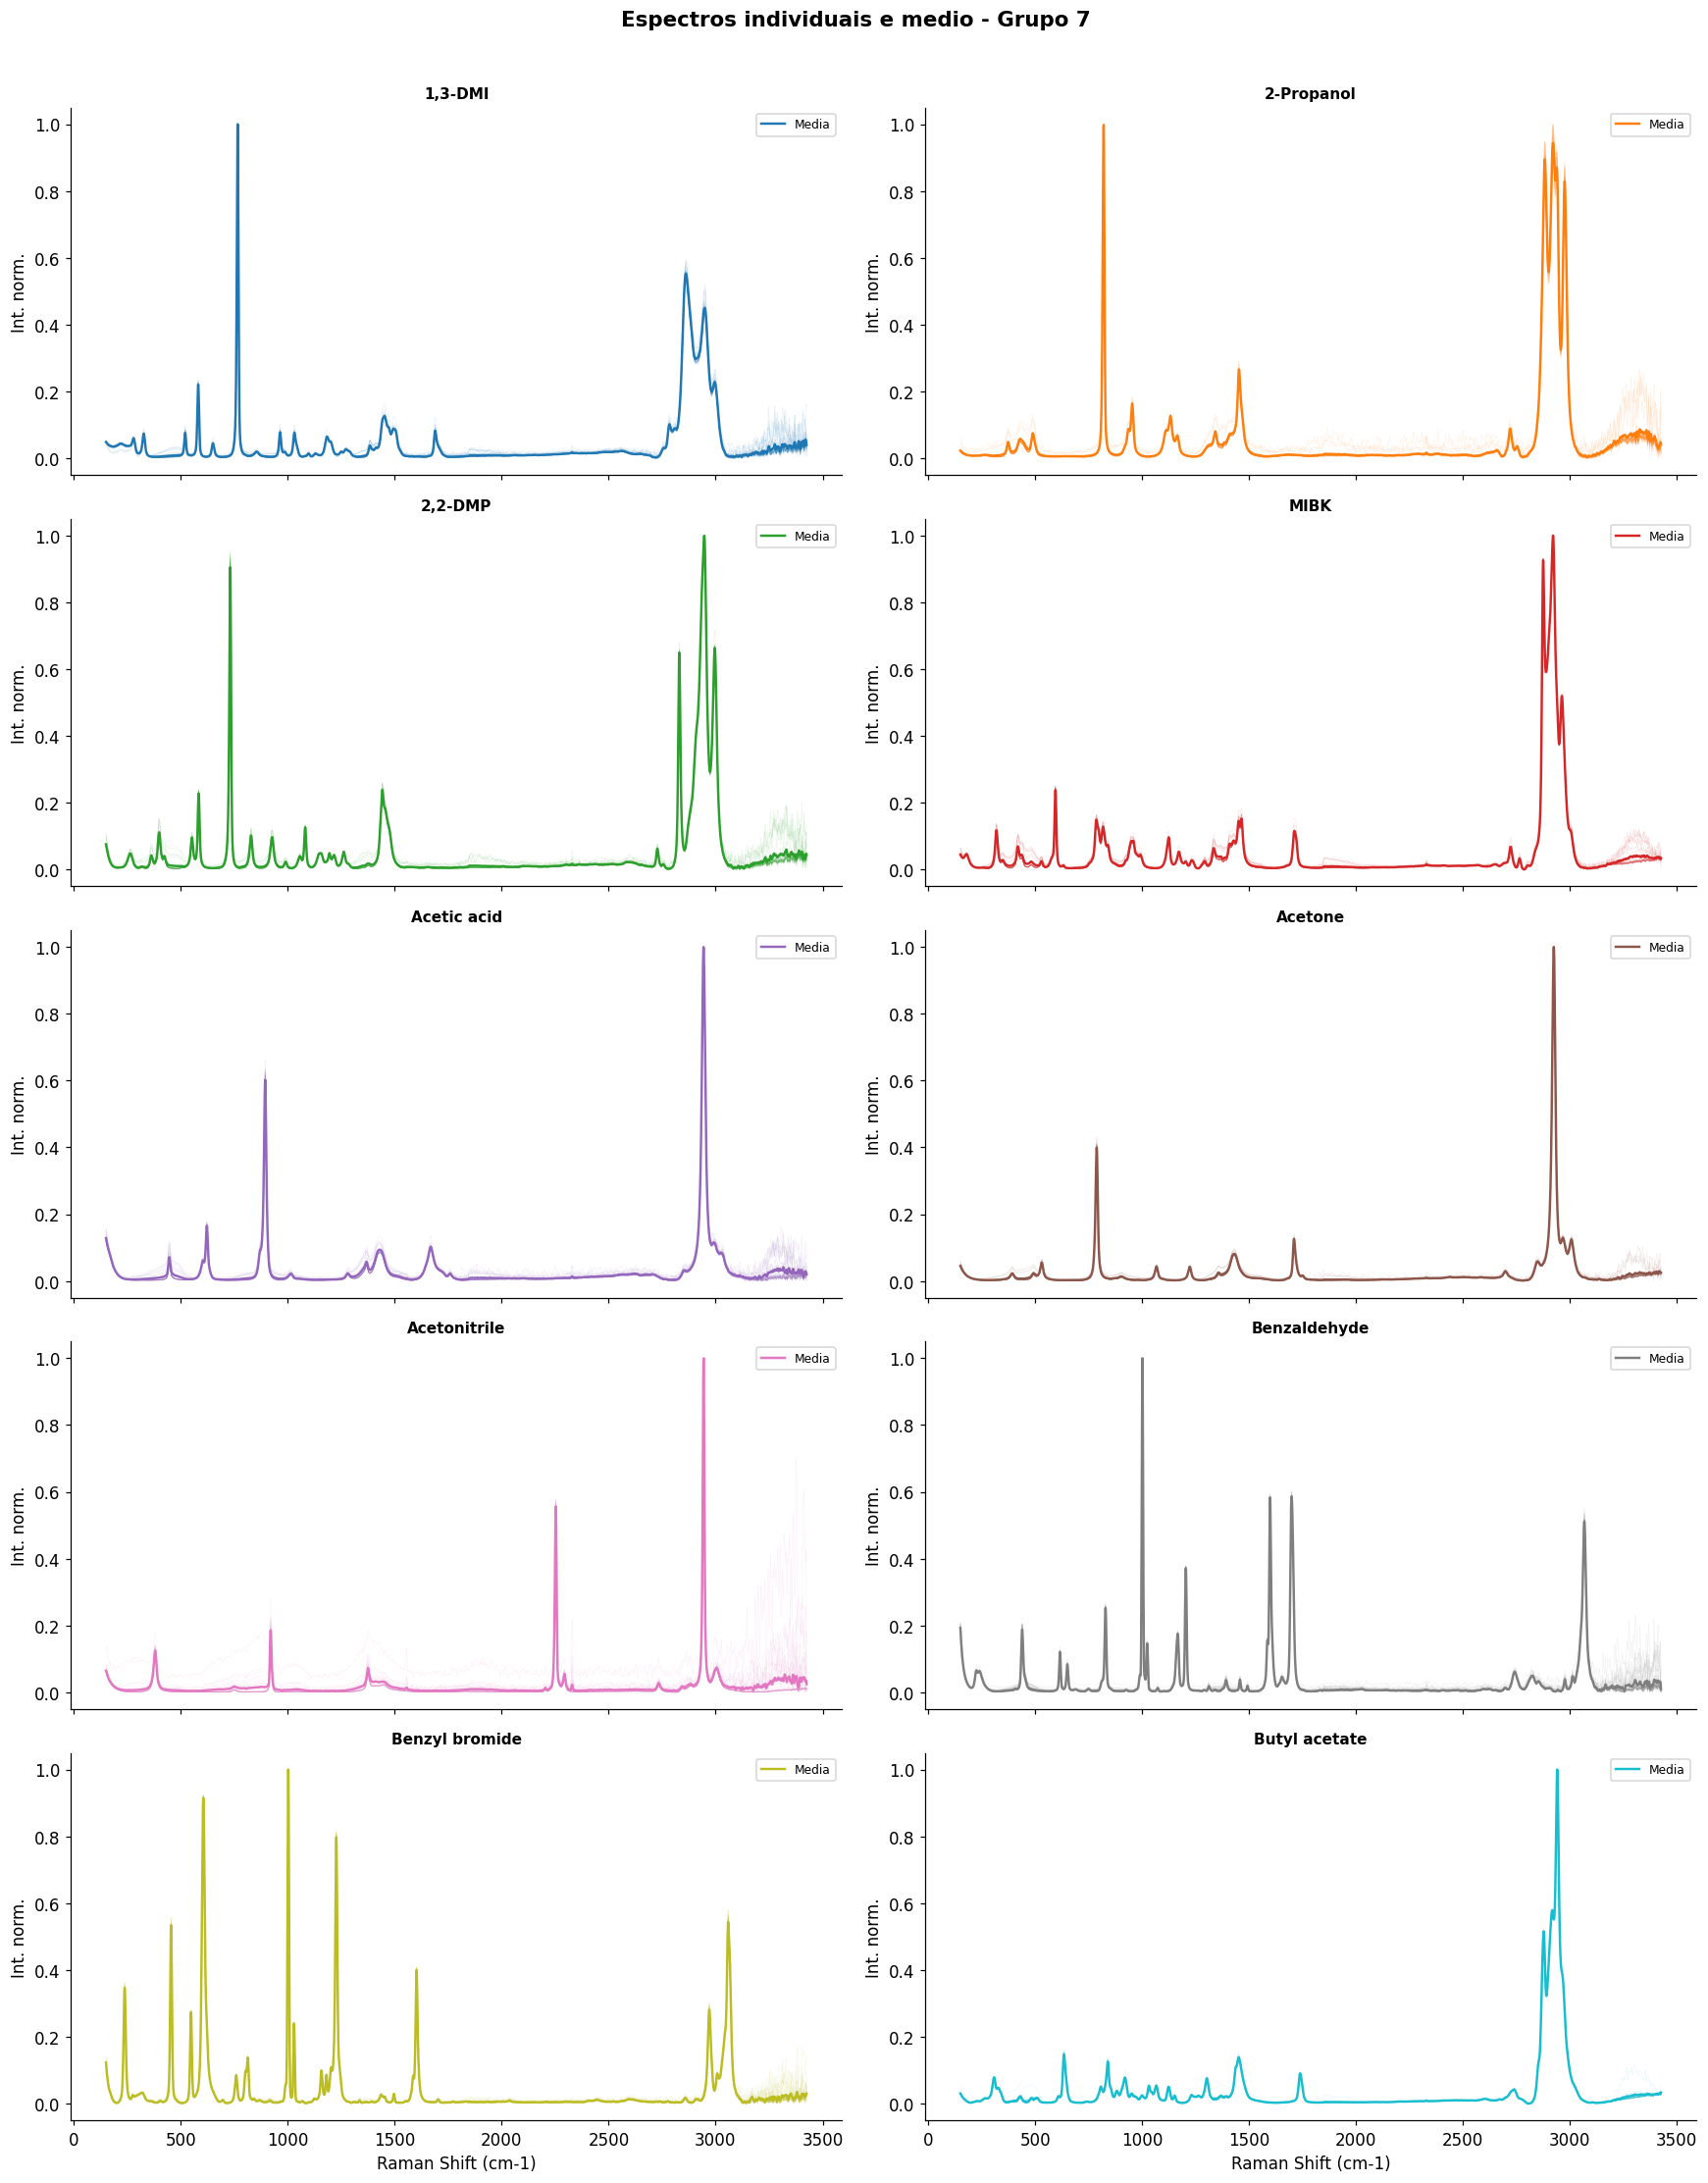

In [7]:
# Espectros individuais + espectro médio por composto
fig, axes = plt.subplots(5, 2, figsize=(16, 20), sharex=True)
axes = axes.flatten()

for i, (c, col) in enumerate(zip(compounds, palette)):
    mask = y_str == c
    sub  = X_norm[mask]
    for spec in sub[::3]:
        axes[i].plot(wavenumbers, spec, color=col, alpha=0.10, linewidth=0.4)
    axes[i].plot(wavenumbers, sub.mean(axis=0), color=col, linewidth=1.6, label='Media')
    axes[i].set_title(c, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Int. norm.')
    axes[i].legend(fontsize=8, loc='upper right')

for ax in axes[-2:]:
    ax.set_xlabel('Raman Shift (cm-1)')

fig.suptitle('Espectros individuais e medio - Grupo 7', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_spectra_individual.png', bbox_inches='tight')
plt.show()


## 4. Comparação dos espetros médios e bandas Raman relevantes

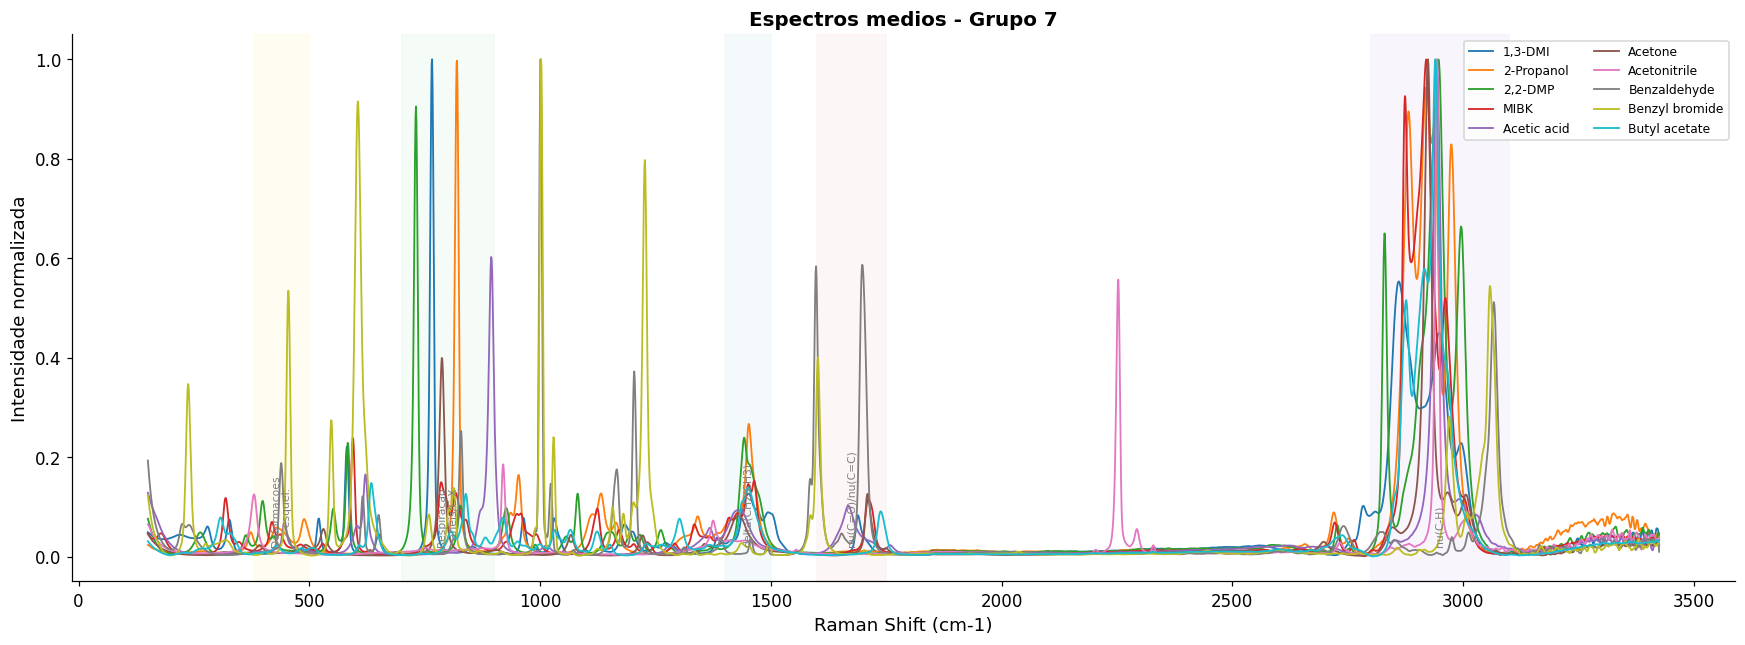

In [8]:
fig, ax = plt.subplots(figsize=(16, 6))
for c, col in zip(compounds, palette):
    mask = y_str == c
    ax.plot(wavenumbers, X_norm[mask].mean(axis=0), label=c, color=col, linewidth=1.2)

ax.set_xlabel('Raman Shift (cm-1)', fontsize=12)
ax.set_ylabel('Intensidade normalizada', fontsize=12)
ax.set_title('Espectros medios - Grupo 7', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, ncol=2, loc='upper right')

# Regiões espetrais
regions = [(380,  500,  'Deformacoes\n  esquel.'),
           (700,  900,  'Respiracao\n  aneis/C-X'),
           (1400, 1500, 'delta(CH2/CH3)'),
           (1600, 1750, 'nu(C=O)/nu(C=C)'),
           (2800, 3100, 'nu(C-H)')]
colors_r = ['#fff9c4','#d4edda','#d1ecf1','#f8d7da','#e2d9f3']
for (x1, x2, label), rc in zip(regions, colors_r):
    ax.axvspan(x1, x2, alpha=0.22, color=rc)
    ax.text((x1+x2)/2, 0.02, label, ha='center', va='bottom',
            fontsize=7, rotation=90, color='grey')

plt.tight_layout()
plt.savefig('fig_mean_spectra.png', bbox_inches='tight')
plt.show()


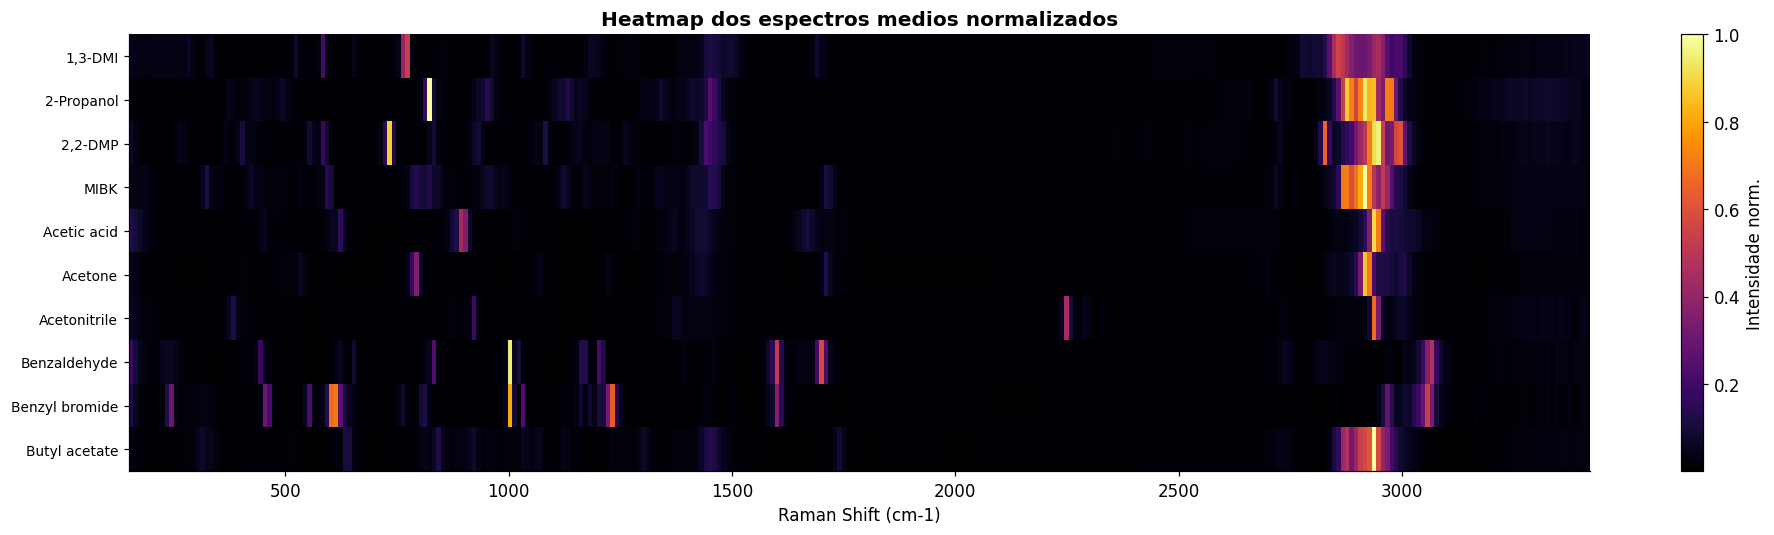

In [9]:
# Heatmap dos espetros médios
mean_matrix = np.vstack([X_norm[y_str == c].mean(axis=0) for c in compounds])
step = 10
wn_sub  = wavenumbers[::step]
mat_sub = mean_matrix[:, ::step]

fig, ax = plt.subplots(figsize=(18, 5))
im = ax.imshow(mat_sub, aspect='auto', cmap='inferno',
               extent=[wn_sub[0], wn_sub[-1], len(compounds)-0.5, -0.5])
ax.set_yticks(range(len(compounds)))
ax.set_yticklabels(compounds, fontsize=9)
ax.set_xlabel('Raman Shift (cm-1)')
ax.set_title('Heatmap dos espectros medios normalizados', fontweight='bold')
plt.colorbar(im, ax=ax, label='Intensidade norm.')
plt.tight_layout()
plt.savefig('fig_heatmap_means.png', bbox_inches='tight')
plt.show()


In [10]:
# Bandas de diagnóstico (picos do espetro médio)
print(f'{"Composto":<22}  {"Principais bandas Raman (cm-1)"}')
print('-' * 70)
for c in compounds:
    mean_spec = X_norm[y_str == c].mean(axis=0)
    peaks, props = find_peaks(mean_spec, height=0.15, distance=10)
    top = peaks[np.argsort(props['peak_heights'])[::-1][:6]]
    bands = ', '.join(f'{wavenumbers[p]:.0f}' for p in sorted(top))
    print(f'{c:<22}  {bands}')


Composto                Principais bandas Raman (cm-1)
----------------------------------------------------------------------
1,3-DMI                 581, 766, 2861, 2948, 2996
2-Propanol              820, 1452, 2882, 2920, 2938, 2975
2,2-DMP                 583, 731, 1442, 2830, 2947, 2996
MIBK                    594, 1464, 2874, 2920, 2962
Acetic acid             622, 894, 2943
Acetone                 787, 2924
Acetonitrile            920, 2253, 2944
Benzaldehyde            828, 1001, 1204, 1598, 1698, 3067
Benzyl bromide          454, 605, 1002, 1227, 1602, 3059
Butyl acetate           2877, 2917, 2940


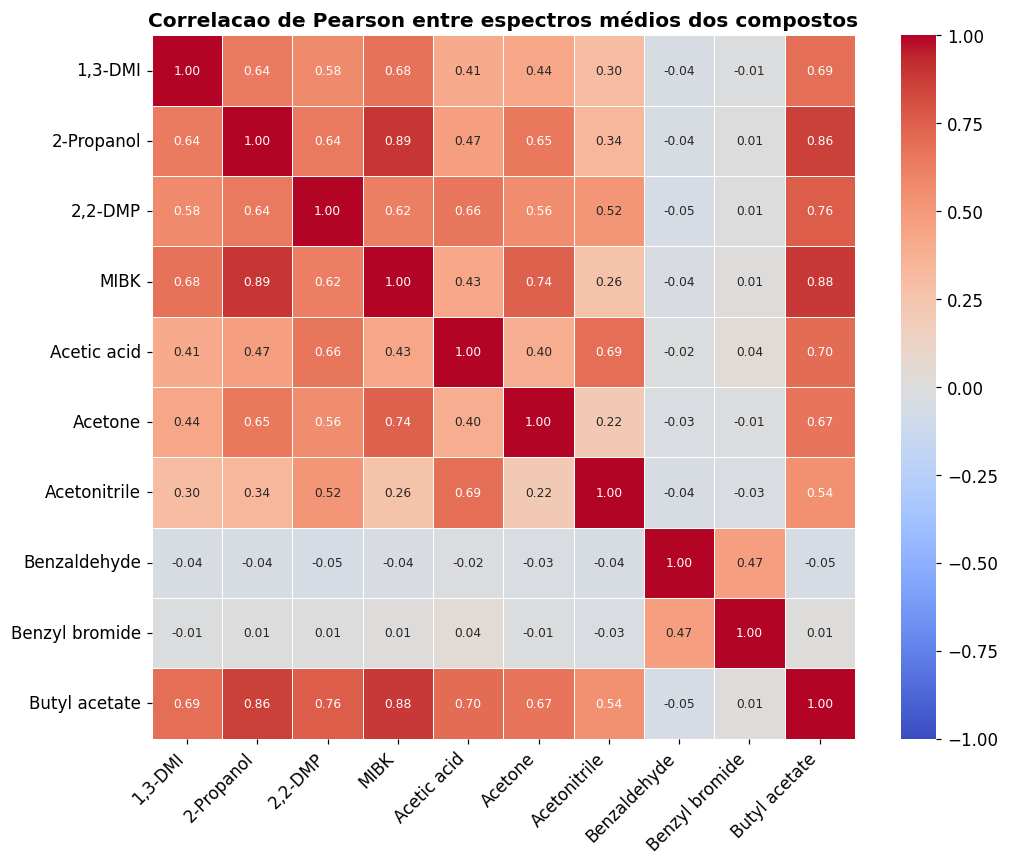


Pares com maior correlação (mais difíceis de distinguir):
  2-Propanol             <-> MIBK                    r = 0.894
  MIBK                   <-> Butyl acetate           r = 0.884
  2-Propanol             <-> Butyl acetate           r = 0.861
  2,2-DMP                <-> Butyl acetate           r = 0.759
  MIBK                   <-> Acetone                 r = 0.744


In [11]:
# 4b. Matriz de correlação entre espetros médios dos compostos. Revela de forma direta quais os pares espetralmente mais semelhantes

mean_matrix = np.vstack([X_norm[y_str == c].mean(axis=0) for c in compounds])
corr_df = pd.DataFrame(mean_matrix, index=compounds).T.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask_upper = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, square=True,
            annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Correlacao de Pearson entre espectros médios dos compostos', fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('fig_correlation_matrix.png', bbox_inches='tight')
plt.show()

print("\nPares com maior correlação (mais difíceis de distinguir):")
corr_vals = []
for i in range(len(compounds)):
    for j in range(i+1, len(compounds)):
        corr_vals.append((corr_df.iloc[i,j], compounds[i], compounds[j]))
corr_vals.sort(reverse=True)
for r, c1, c2 in corr_vals[:5]:
    print(f"  {c1:<22} <-> {c2:<22}  r = {r:.3f}")

### 4c. Tabela de Bandas Raman de Diagnóstico

Bandas características dos 10 compostos cruzadas com literatura (SDBS / NIST):

| Composto | Banda (cm⁻¹) | Atribuição | Fonte |
|---|---|---|---|
| Acetonitrile | 918, 2253 | ν(C–C) / ν(C≡N) | SDBS |
| Acetone | 789, 1709 | ν(C–C) / ν(C=O) | NIST |
| MIBK | 1714 | ν(C=O) cetona alifática | SDBS |
| Acetic acid | 893, 1712 | ν(C–C) / ν(C=O) OH alargado | NIST |
| Butyl acetate | 1738 | ν(C=O) éster | SDBS |
| 2-Propanol | 820, 953 | ν(C–O) álcool secundário | NIST |
| Benzaldehyde | 1001, 1601, 3067 | respiração anel / ν(C=C) / ν(C–H arom.) | SDBS |
| Benzyl bromide | 1002, 1208, 3065 | respiração anel / ν(C–Br) / ν(C–H arom.) | SDBS |
| 1,3-DMI | 1085, 1287, 1669 | ν(C–N) / ν(C–N) / ν(C=O) imida | SDBS |
| 2,2-DMP | 1065, 1190 | ν(C–O) acetal simétrico/assimétrico | SDBS |

> A banda do nitrilo (~2253 cm⁻¹) do Acetonitrile é única neste conjunto e serve como impressão digital imediata. Os compostos aromáticos destacam-se pela respiração do anel a ~1001 cm⁻¹ e pelas bandas C–H aromáticas acima de 3000 cm⁻¹.

## 5. Análise Multivariada Não Supervisionada

### 5.1 PCA

PC1: 46.5%   PC2: 16.4%   PC3: 9.7%
Componentes para 95% variancia: 7


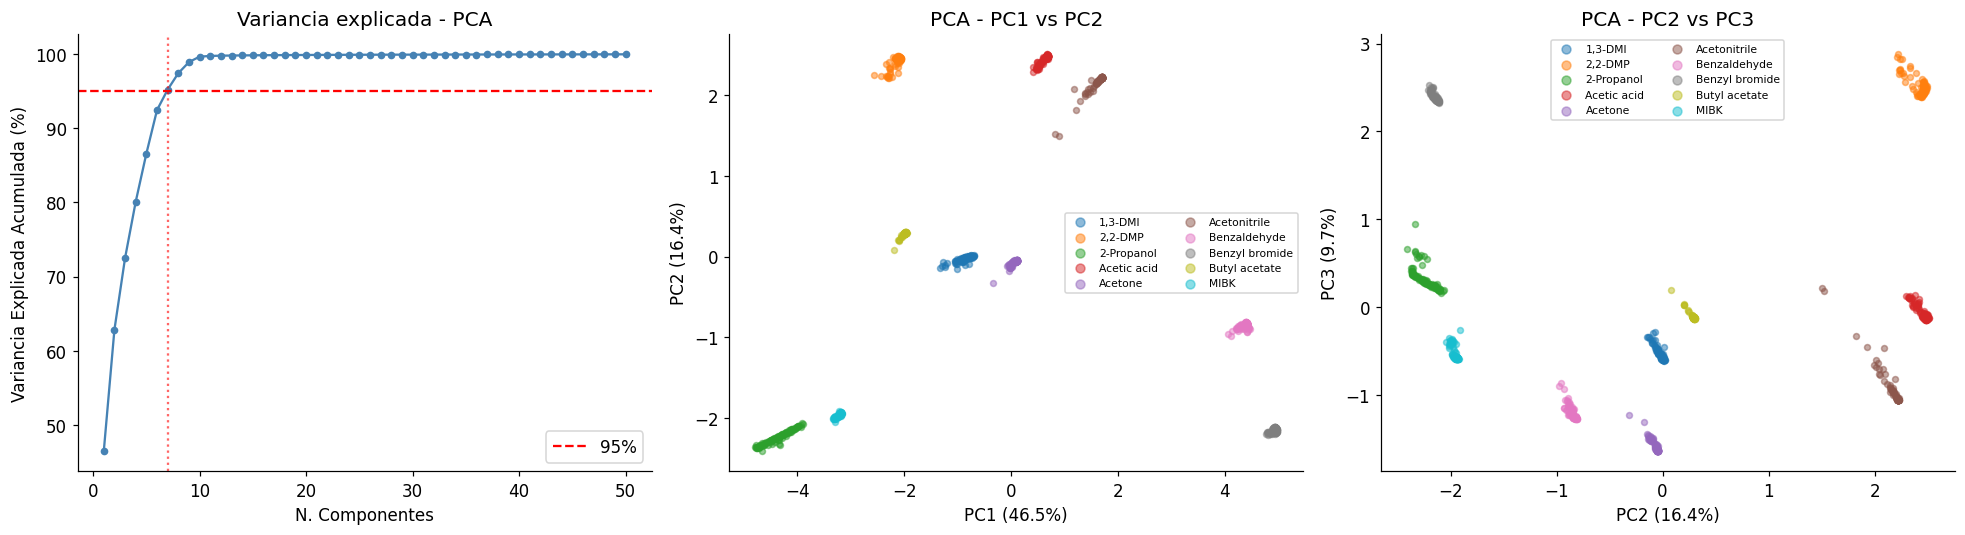

In [12]:
le = LabelEncoder()
y_enc = le.fit_transform(y_str)

pca = PCA(n_components=50, random_state=SEED)
X_pca = pca.fit_transform(X_norm)

explained = np.cumsum(pca.explained_variance_ratio_) * 100
n95 = int(np.searchsorted(explained, 95)) + 1
print(f'PC1: {pca.explained_variance_ratio_[0]*100:.1f}%   '
      f'PC2: {pca.explained_variance_ratio_[1]*100:.1f}%   '
      f'PC3: {pca.explained_variance_ratio_[2]*100:.1f}%')
print(f'Componentes para 95% variancia: {n95}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Variância acumulada
axes[0].plot(range(1, 51), explained, 'o-', color='steelblue', ms=4)
axes[0].axhline(95, color='red', linestyle='--', label='95%')
axes[0].axvline(n95, color='red', linestyle=':', alpha=0.6)
axes[0].set_xlabel('N. Componentes')
axes[0].set_ylabel('Variancia Explicada Acumulada (%)')
axes[0].set_title('Variancia explicada - PCA')
axes[0].legend()

# Scores PC1 vs PC2
for i, (c, col) in enumerate(zip(le.classes_, palette)):
    mask = y_enc == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=col, s=15, alpha=0.5, label=c)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA - PC1 vs PC2')
axes[1].legend(fontsize=7, markerscale=1.5, ncol=2)

# Scores PC2 vs PC3
for i, (c, col) in enumerate(zip(le.classes_, palette)):
    mask = y_enc == i
    axes[2].scatter(X_pca[mask, 1], X_pca[mask, 2],
                    color=col, s=15, alpha=0.5, label=c)
axes[2].set_xlabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[2].set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')
axes[2].set_title('PCA - PC2 vs PC3')
axes[2].legend(fontsize=7, markerscale=1.5, ncol=2)

plt.tight_layout()
plt.savefig('fig_pca.png', bbox_inches='tight')
plt.show()


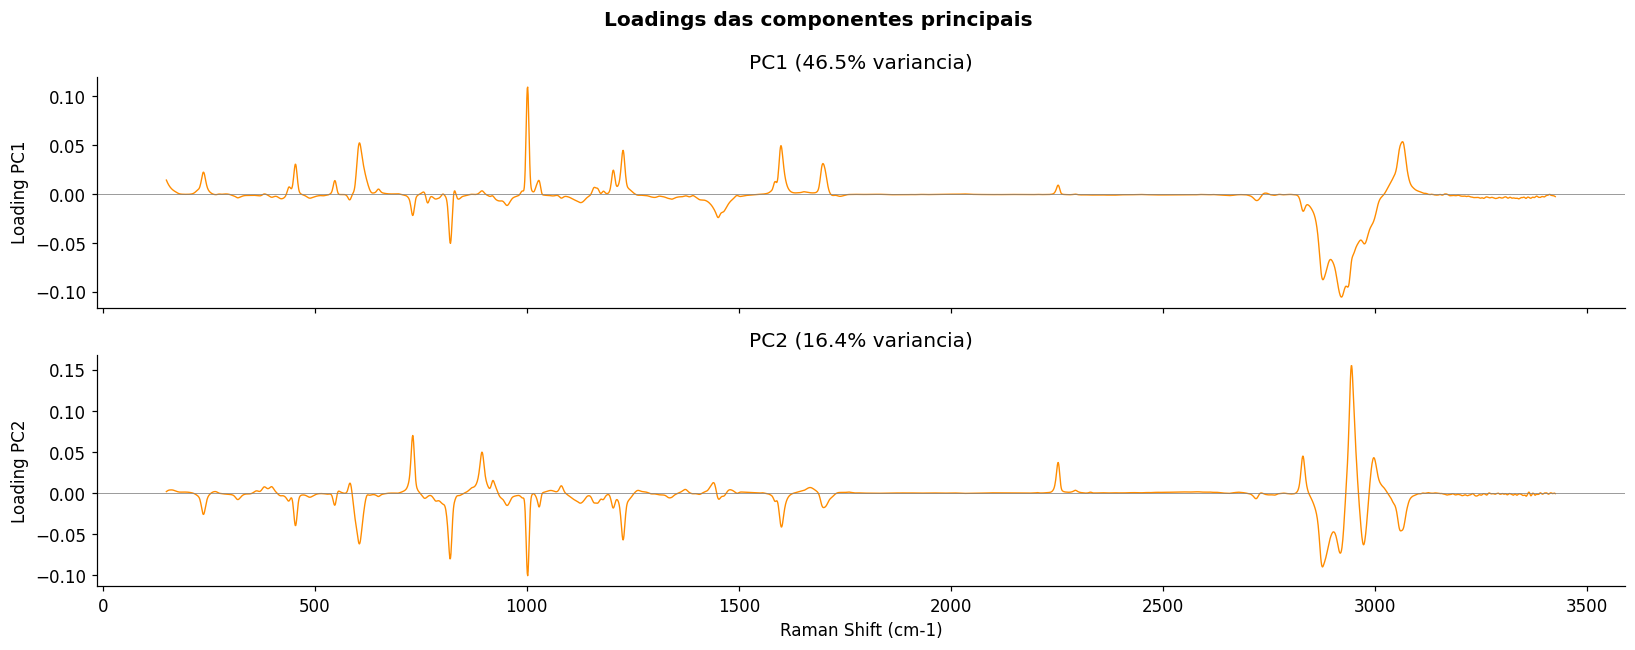

In [13]:
# Loadings das primeiras duas PCs
fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
for k, ax in enumerate(axes):
    ax.plot(wavenumbers, pca.components_[k], color='darkorange', linewidth=0.9)
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.set_ylabel(f'Loading PC{k+1}')
    ax.set_title(f'PC{k+1} ({pca.explained_variance_ratio_[k]*100:.1f}% variancia)')
axes[1].set_xlabel('Raman Shift (cm-1)')
fig.suptitle('Loadings das componentes principais', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_pca_loadings.png', bbox_inches='tight')
plt.show()


### 5.2 t-SNE

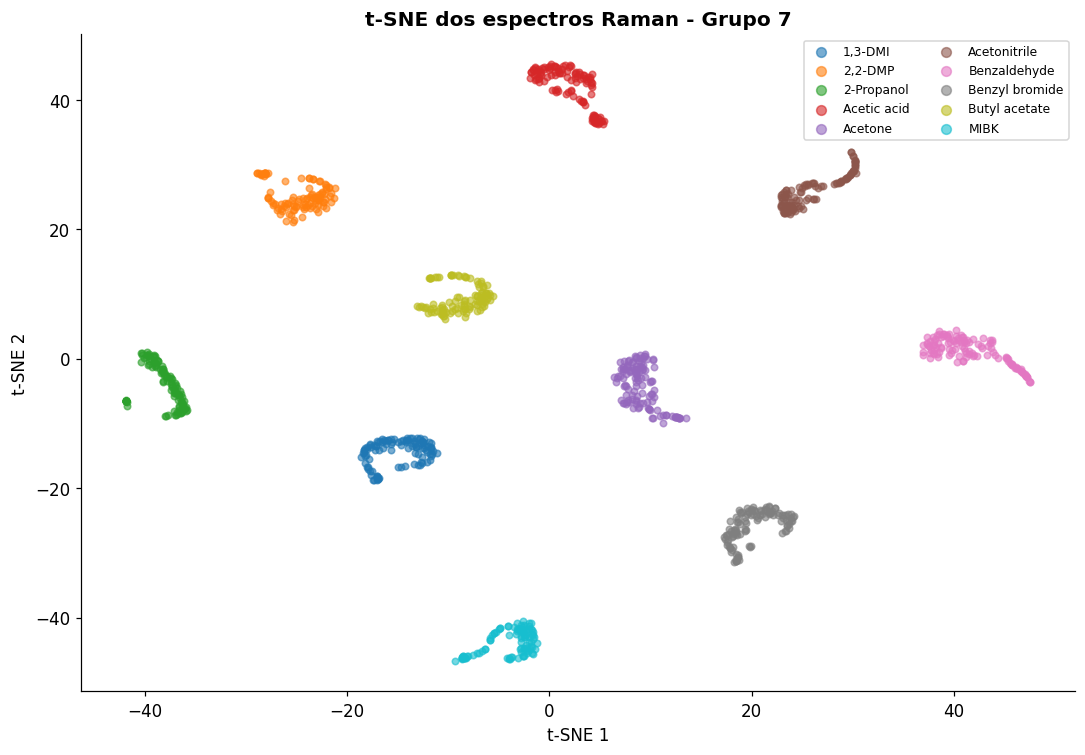

In [14]:
tsne = TSNE(n_components=2, perplexity=40, max_iter=1500,
           random_state=SEED, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_pca[:, :30])

fig, ax = plt.subplots(figsize=(10, 7))
for i, (c, col) in enumerate(zip(le.classes_, palette)):
    mask = y_enc == i
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               color=col, s=18, alpha=0.6, label=c)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE dos espectros Raman - Grupo 7', fontweight='bold')
ax.legend(fontsize=8, markerscale=1.5, ncol=2)
plt.tight_layout()
plt.savefig('fig_tsne.png', bbox_inches='tight')
plt.show()


### 5.3 UMAP

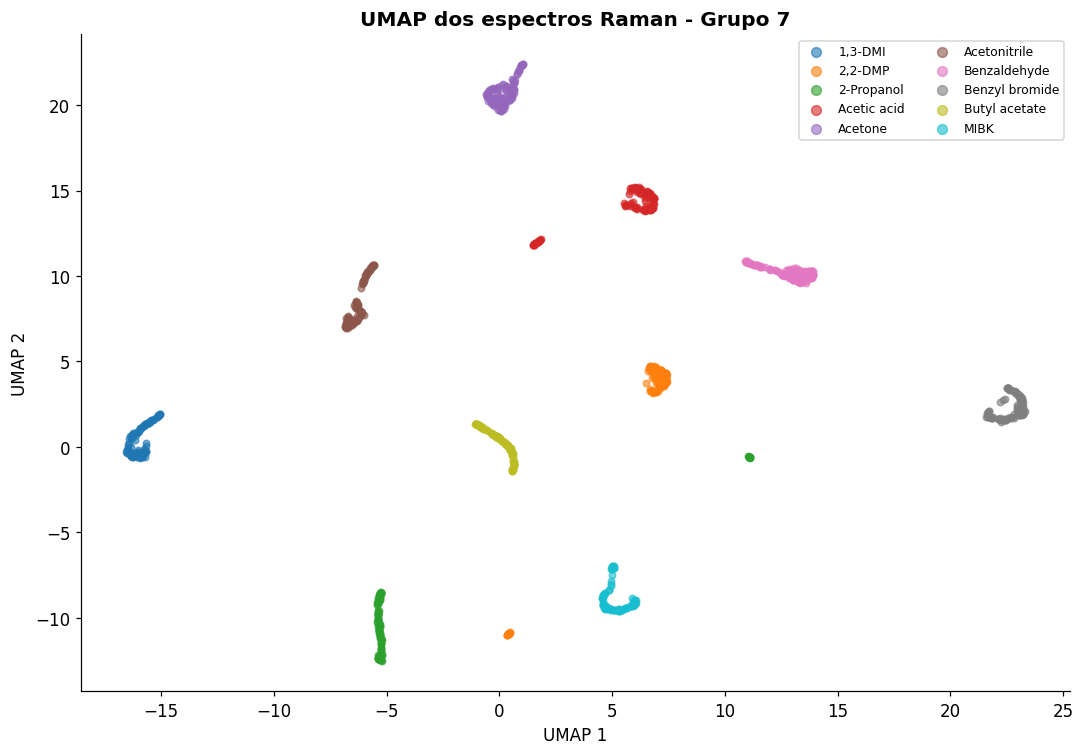

In [15]:
reducer = umap_.UMAP(n_neighbors=20, min_dist=0.1,
                    n_components=2, random_state=SEED)
X_umap = reducer.fit_transform(X_norm)

fig, ax = plt.subplots(figsize=(10, 7))
for i, (c, col) in enumerate(zip(le.classes_, palette)):
    mask = y_enc == i
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
               color=col, s=18, alpha=0.6, label=c)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP dos espectros Raman - Grupo 7', fontweight='bold')
ax.legend(fontsize=8, markerscale=1.5, ncol=2)
plt.tight_layout()
plt.savefig('fig_umap.png', bbox_inches='tight')
plt.show()


## 6. Clustering

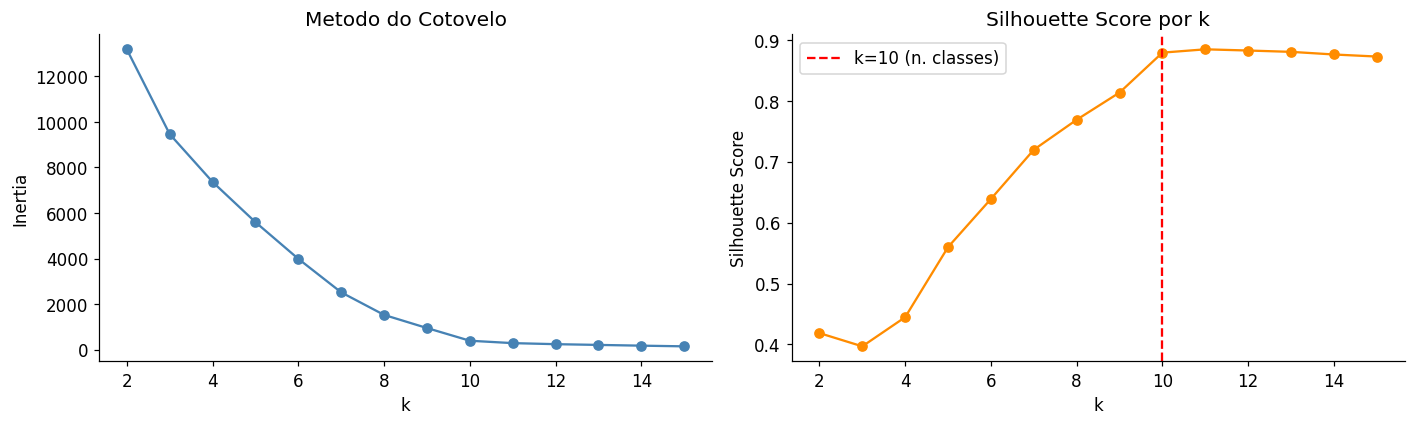

In [16]:
# K-Means - selecão de k (cotovelo + silhouette)
inertias, silhouettes = [], []
k_range = range(2, 16)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels_k = km.fit_predict(X_pca[:, :30])
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca[:, :30], labels_k))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(k_range, inertias, 'o-', color='steelblue')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Metodo do Cotovelo')
axes[1].plot(k_range, silhouettes, 'o-', color='darkorange')
axes[1].axvline(10, color='red', linestyle='--', label='k=10 (n. classes)')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por k')
axes[1].legend()
plt.tight_layout()
plt.savefig('fig_kmeans_selection.png', bbox_inches='tight')
plt.show()


K-Means (k=10)  ARI = 1.000   Silhouette = 0.879


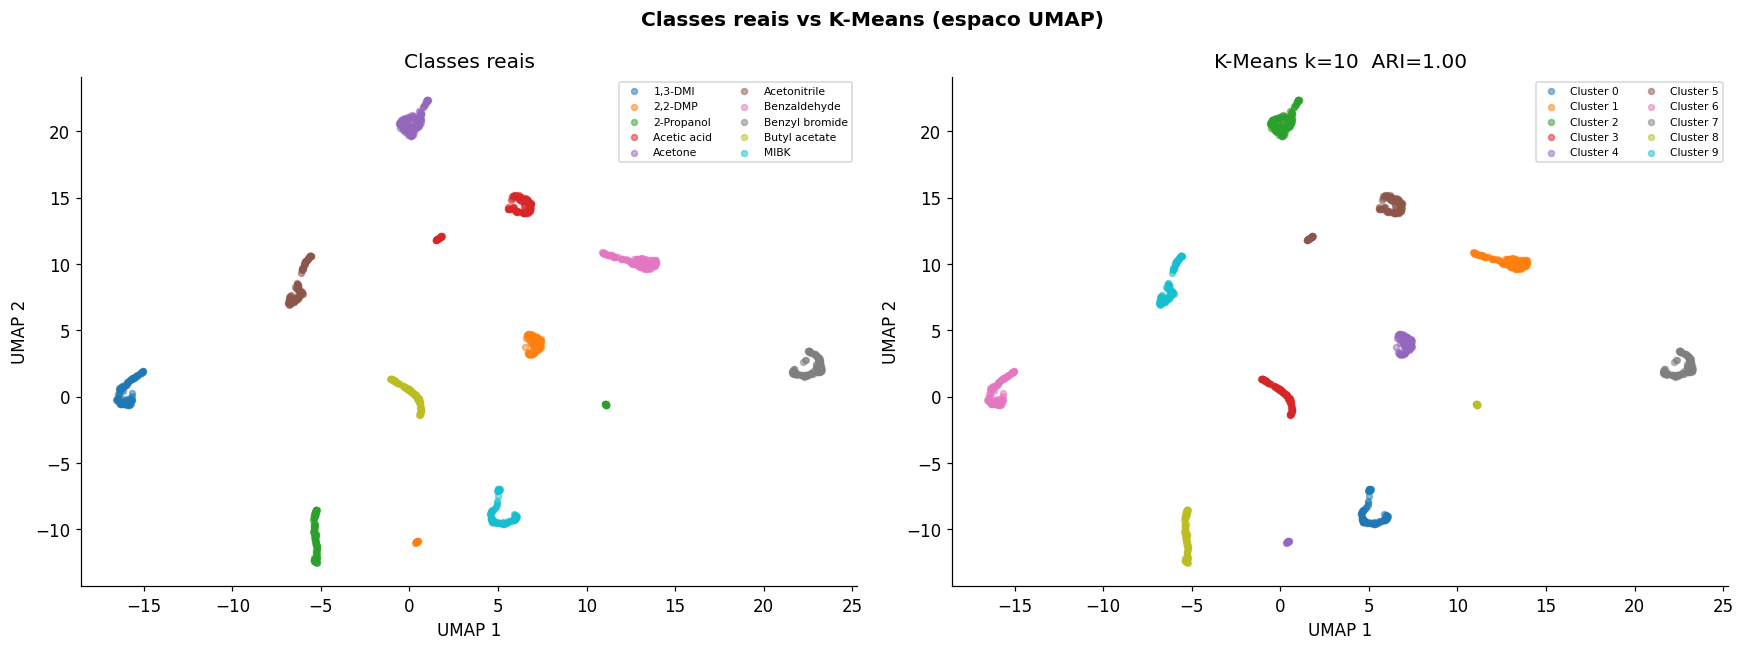

In [17]:
# K-Means k=10
km10 = KMeans(n_clusters=10, random_state=SEED, n_init=20)
cluster_labels = km10.fit_predict(X_pca[:, :30])

ari = adjusted_rand_score(y_enc, cluster_labels)
sil = silhouette_score(X_pca[:, :30], cluster_labels)
print(f'K-Means (k=10)  ARI = {ari:.3f}   Silhouette = {sil:.3f}')

cmap_c = plt.colormaps.get_cmap('tab10')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, (c, col) in enumerate(zip(le.classes_, palette)):
    mask = y_enc == i
    axes[0].scatter(X_umap[mask, 0], X_umap[mask, 1],
                    color=col, s=15, alpha=0.5, label=c)
axes[0].set_title('Classes reais'); axes[0].legend(fontsize=7, ncol=2)
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')

for cl in range(10):
    mask = cluster_labels == cl
    axes[1].scatter(X_umap[mask, 0], X_umap[mask, 1],
                    color=cmap_c(cl/10), s=15, alpha=0.5, label=f'Cluster {cl}')
axes[1].set_title(f'K-Means k=10  ARI={ari:.2f}')
axes[1].legend(fontsize=7, ncol=2)
axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')

plt.suptitle('Classes reais vs K-Means (espaco UMAP)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_clustering_umap.png', bbox_inches='tight')
plt.show()


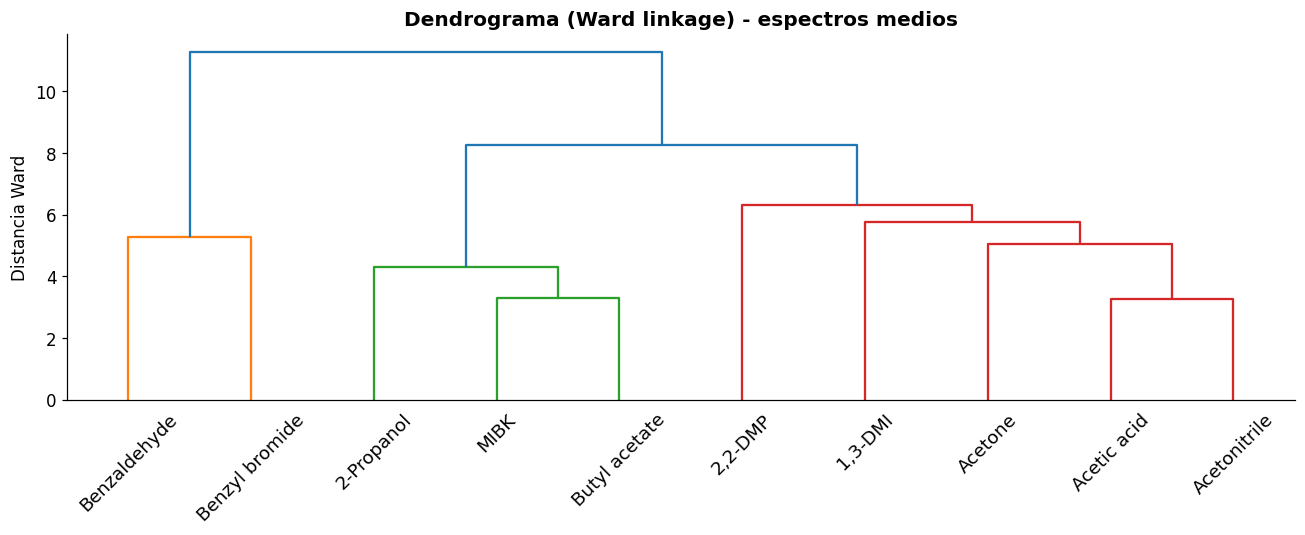


Interpretacao:
- Compostos aromáticos (Benzaldehyde, Benzyl bromide) agrupam-se pela banda do anel
  a ~1001 cm-1 e bandas C-H aromáticas a ~3060 cm-1.
- Cetonas (Acetone, MIBK) e ester (Butyl acetate) partilham a banda C=O ~1700 cm-1.
- Acetonitrile destaca-se pelo nitrilo a ~2253 cm-1, formando um cluster isolado.
- 1,3-DMI (heterociclo N) e 2-Propanol (álcool) tendem a separar-se das restantes.



In [18]:
# Dendrograma hierárquico (Ward) sobre espetros médios
mean_pca = np.vstack([X_pca[y_str == c, :30].mean(axis=0) for c in compounds])
Z = linkage(mean_pca, method='ward')

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, labels=compounds, ax=ax, leaf_rotation=45,
           color_threshold=0.7*max(Z[:, 2]))
ax.set_title('Dendrograma (Ward linkage) - espectros medios', fontweight='bold')
ax.set_ylabel('Distancia Ward')
plt.tight_layout()
plt.savefig('fig_dendrogram.png', bbox_inches='tight')
plt.show()

print('''
Interpretacao:
- Compostos aromáticos (Benzaldehyde, Benzyl bromide) agrupam-se pela banda do anel
  a ~1001 cm-1 e bandas C-H aromáticas a ~3060 cm-1.
- Cetonas (Acetone, MIBK) e ester (Butyl acetate) partilham a banda C=O ~1700 cm-1.
- Acetonitrile destaca-se pelo nitrilo a ~2253 cm-1, formando um cluster isolado.
- 1,3-DMI (heterociclo N) e 2-Propanol (álcool) tendem a separar-se das restantes.
''')


## 7. Análise Preditiva - Classificação do Composto

KNN (k=5)                     Acc = 1.0000 +/- 0.0000
SVM (RBF)                     Acc = 1.0000 +/- 0.0000
Random Forest                 Acc = 1.0000 +/- 0.0000
Gradient Boosting             Acc = 0.9964 +/- 0.0034
Logistic Regression           Acc = 1.0000 +/- 0.0000


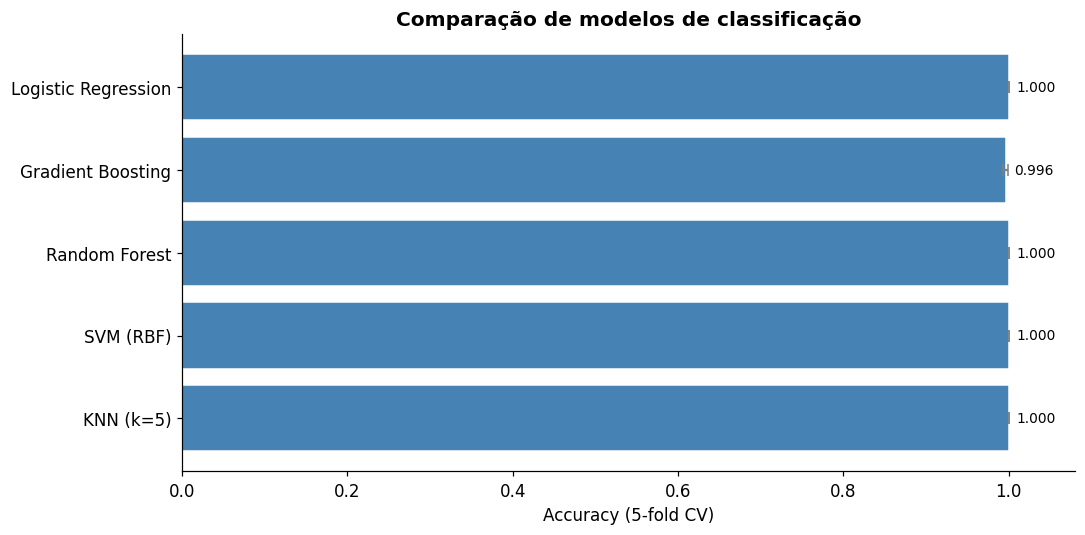

In [19]:
X_clf = X_pca[:, :n95]
y_clf = y_enc
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'KNN (k=5)':               KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)':               SVC(C=10, gamma='scale', random_state=SEED),
    'Random Forest':           RandomForestClassifier(n_estimators=200, random_state=SEED,
                                                       n_jobs=-1),
    'Gradient Boosting':       GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                                           random_state=SEED),
    'Logistic Regression':     LogisticRegression(C=1, max_iter=2000,
                                                   random_state=SEED, n_jobs=-1),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_clf, y_clf, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f'{name:<28}  Acc = {scores.mean():.4f} +/- {scores.std():.4f}')

# Grafico de comparacao
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
means = [results[n].mean() for n in names]
stds  = [results[n].std()  for n in names]
bars = ax.barh(names, means, xerr=stds, color='steelblue', edgecolor='white',
               error_kw=dict(ecolor='grey', capsize=4))
ax.set_xlabel('Accuracy (5-fold CV)')
ax.set_title('Comparação de modelos de classificação', fontweight='bold')
ax.set_xlim(0, 1.08)
for bar, m in zip(bars, means):
    ax.text(m + 0.01, bar.get_y() + bar.get_height()/2,
            f'{m:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_model_comparison.png', bbox_inches='tight')
plt.show()


Melhor modelo: KNN (k=5) (Acc=1.0000)
Accuracy no conjunto de teste (20%): 1.0000

                precision    recall  f1-score   support

       1,3-DMI       1.00      1.00      1.00        22
       2,2-DMP       1.00      1.00      1.00        21
    2-Propanol       1.00      1.00      1.00        22
   Acetic acid       1.00      1.00      1.00        23
       Acetone       1.00      1.00      1.00        24
  Acetonitrile       1.00      1.00      1.00        21
  Benzaldehyde       1.00      1.00      1.00        24
Benzyl bromide       1.00      1.00      1.00        23
 Butyl acetate       1.00      1.00      1.00        21
          MIBK       1.00      1.00      1.00        20

      accuracy                           1.00       221
     macro avg       1.00      1.00      1.00       221
  weighted avg       1.00      1.00      1.00       221



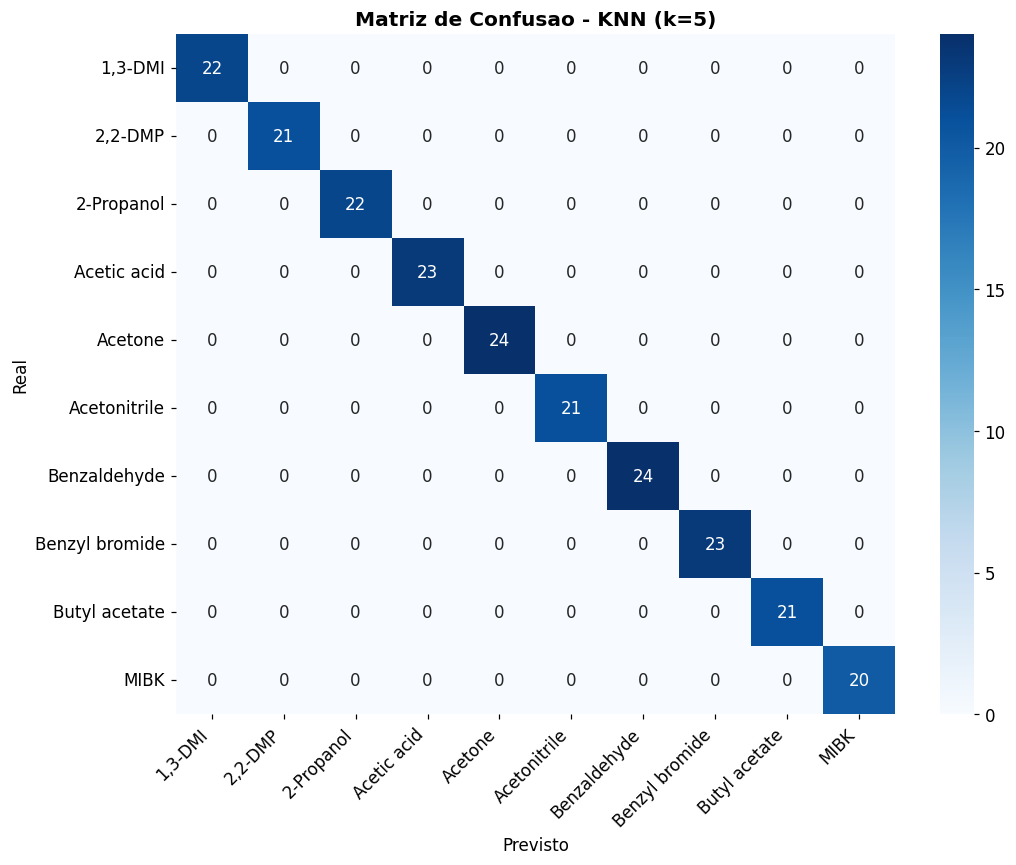

In [20]:
# Melhor modelo - avaliação detalhada
best_name = max(results, key=lambda n: results[n].mean())
print(f'Melhor modelo: {best_name} (Acc={results[best_name].mean():.4f})')

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=SEED)

best_model = models[best_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy no conjunto de teste (20%): {acc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm_mat = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Previsto'); ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusao - {best_name}', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', bbox_inches='tight')
plt.show()


## 7b. Classificação por Família Química

O enunciado pede também a classificação por **família química**. Este problema é mais exigente do que a identificação por composto: cetonas (Acetone, MIBK) e éster/ácido (Butyl acetate, Acetic acid) partilham a banda C=O, tornando a separação dependente de diferenças subtis nas regiões C–C e C–O.

In [21]:
# 7b.1  Definição das famílias químicas

FAMILY_MAP = {
    '1,3-DMI':        'Heterociclo',
    '2-Propanol':     'Álcool',
    '2,2-DMP':        'Acetal',
    'MIBK':           'Cetona',
    'Acetic acid':    'Ácido',
    'Acetone':        'Cetona',
    'Acetonitrile':   'Nitrilo',
    'Benzaldehyde':   'Aromático',
    'Benzyl bromide': 'Aromático',
    'Butyl acetate':  'Ester',
}
y_family = np.array([FAMILY_MAP[c] for c in y_str])
le_fam = LabelEncoder()
y_fam_enc = le_fam.fit_transform(y_family)
families = list(le_fam.classes_)
print('Familias:', families)
print('Distribuicao:')
for f in families:
    print(f'  {f:<12}: {(y_family == f).sum()} espectros')

Familias: [np.str_('Acetal'), np.str_('Aromático'), np.str_('Cetona'), np.str_('Ester'), np.str_('Heterociclo'), np.str_('Nitrilo'), np.str_('Ácido'), np.str_('Álcool')]
Distribuicao:
  Acetal      : 107 espectros
  Aromático   : 233 espectros
  Cetona      : 220 espectros
  Ester       : 106 espectros
  Heterociclo : 109 espectros
  Nitrilo     : 104 espectros
  Ácido       : 113 espectros
  Álcool      : 109 espectros


KNN (k=5)                     Acc = 1.0000 +/- 0.0000
SVM (RBF)                     Acc = 1.0000 +/- 0.0000
Random Forest                 Acc = 1.0000 +/- 0.0000
Gradient Boosting             Acc = 0.9964 +/- 0.0034
Logistic Regression           Acc = 1.0000 +/- 0.0000


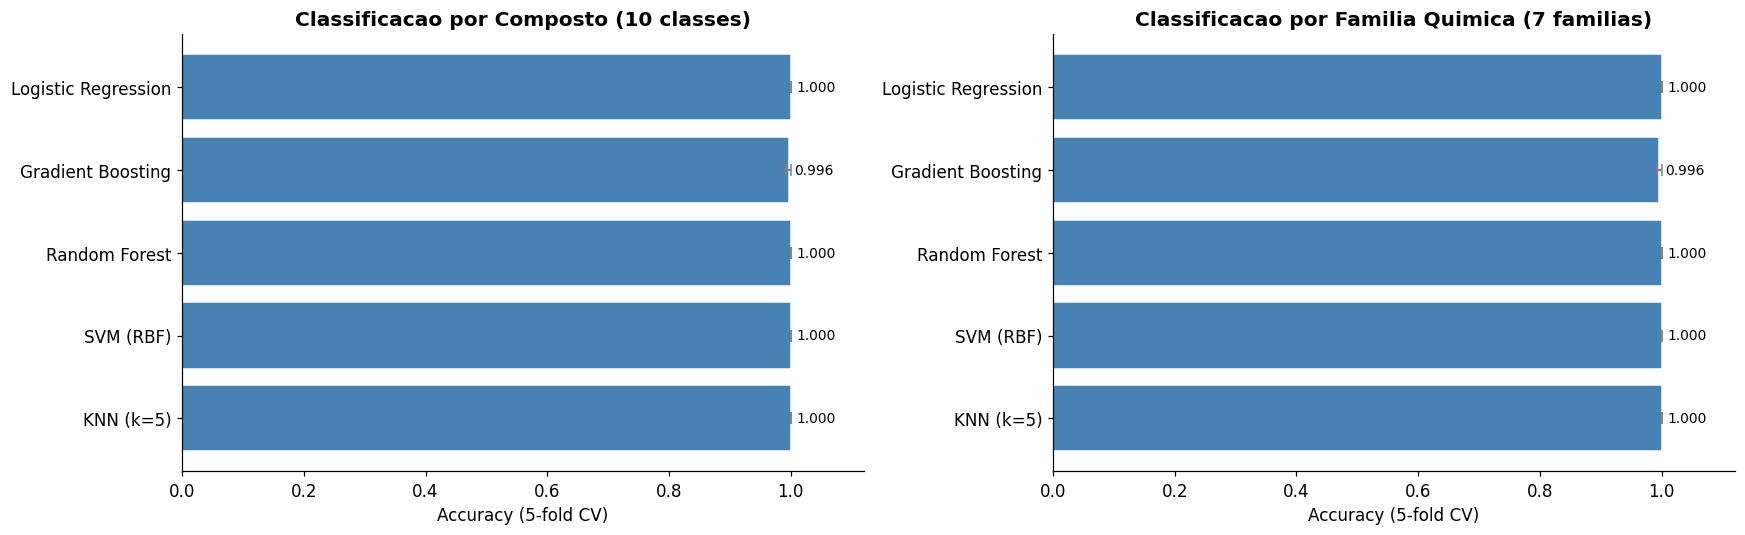

In [22]:
# 7b.2  Comparacao de modelos — familia quimica

X_clf_fam = X_pca[:, :n95]
cv_fam = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models_fam = {
    'KNN (k=5)':           KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)':           SVC(C=10, gamma='scale', random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=SEED),
    'Logistic Regression': LogisticRegression(C=1, max_iter=2000, random_state=SEED, n_jobs=-1),
}

results_fam = {}
for name, model in models_fam.items():
    scores = cross_val_score(model, X_clf_fam, y_fam_enc, cv=cv_fam, scoring='accuracy', n_jobs=-1)
    results_fam[name] = scores
    print(f'{name:<28}  Acc = {scores.mean():.4f} +/- {scores.std():.4f}')

# Comparação composto vs família
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, res, title in zip(axes,
                           [results, results_fam],
                           ['Classificacao por Composto (10 classes)',
                            'Classificacao por Familia Quimica (7 familias)']):
    names_r = list(res.keys())
    means_r = [res[n].mean() for n in names_r]
    stds_r  = [res[n].std()  for n in names_r]
    bars = ax.barh(names_r, means_r, xerr=stds_r, color='steelblue', edgecolor='white',
                   error_kw=dict(ecolor='grey', capsize=4))
    ax.set_xlabel('Accuracy (5-fold CV)')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 1.12)
    for bar, m in zip(bars, means_r):
        ax.text(m + 0.01, bar.get_y() + bar.get_height()/2,
                f'{m:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_family_classification.png', bbox_inches='tight')
plt.show()

Melhor modelo (familia): KNN (k=5)  Acc=1.0000

              precision    recall  f1-score   support

      Acetal       1.00      1.00      1.00        21
   Aromático       1.00      1.00      1.00        47
      Cetona       1.00      1.00      1.00        44
       Ester       1.00      1.00      1.00        21
 Heterociclo       1.00      1.00      1.00        22
     Nitrilo       1.00      1.00      1.00        21
       Ácido       1.00      1.00      1.00        23
      Álcool       1.00      1.00      1.00        22

    accuracy                           1.00       221
   macro avg       1.00      1.00      1.00       221
weighted avg       1.00      1.00      1.00       221



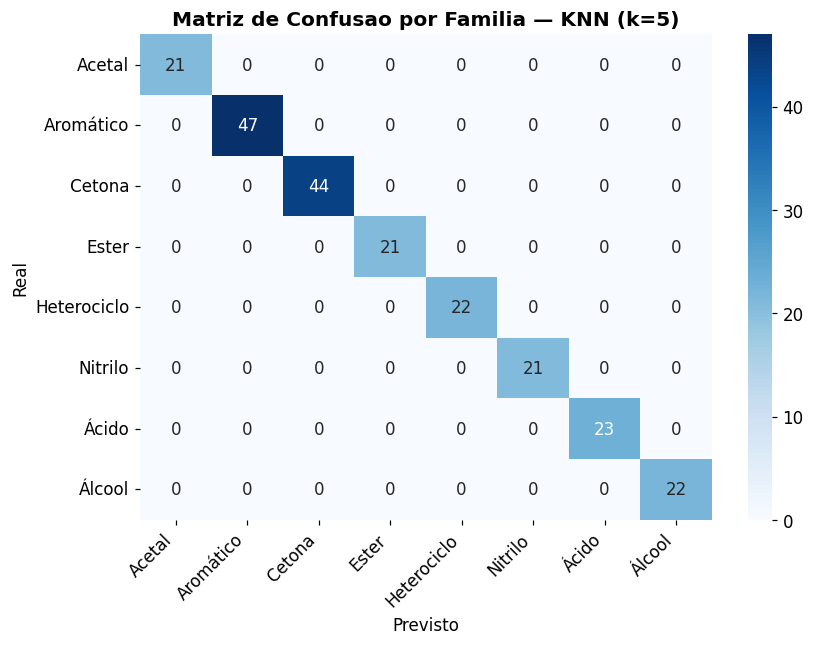


Nota: A classificação por família é mais exigente do que por composto.
Os erros esperados concentram-se em Cetona vs Ester/Ácido (todos com banda C=O)
e nos Aromáticos (Benzaldehyde vs Benzyl bromide sao espetralmente próximos).



In [23]:
# Melhor modelo família — matriz de confusão
best_fam = max(results_fam, key=lambda n: results_fam[n].mean())
print(f'Melhor modelo (familia): {best_fam}  Acc={results_fam[best_fam].mean():.4f}')

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf_fam, y_fam_enc, test_size=0.2, stratify=y_fam_enc, random_state=SEED)
models_fam[best_fam].fit(X_tr, y_tr)
y_pred_fam = models_fam[best_fam].predict(X_te)

print()
print(classification_report(y_te, y_pred_fam, target_names=le_fam.classes_))

cm_fam = confusion_matrix(y_te, y_pred_fam)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_fam, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_fam.classes_, yticklabels=le_fam.classes_, ax=ax)
ax.set_xlabel('Previsto'); ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusao por Familia — {best_fam}', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig_confusion_family.png', bbox_inches='tight')
plt.show()

print("""
Nota: A classificação por família é mais exigente do que por composto.
Os erros esperados concentram-se em Cetona vs Ester/Ácido (todos com banda C=O)
e nos Aromáticos (Benzaldehyde vs Benzyl bromide sao espetralmente próximos).
""")

## 8. Importância das Variáveis e Interpretação Espetral

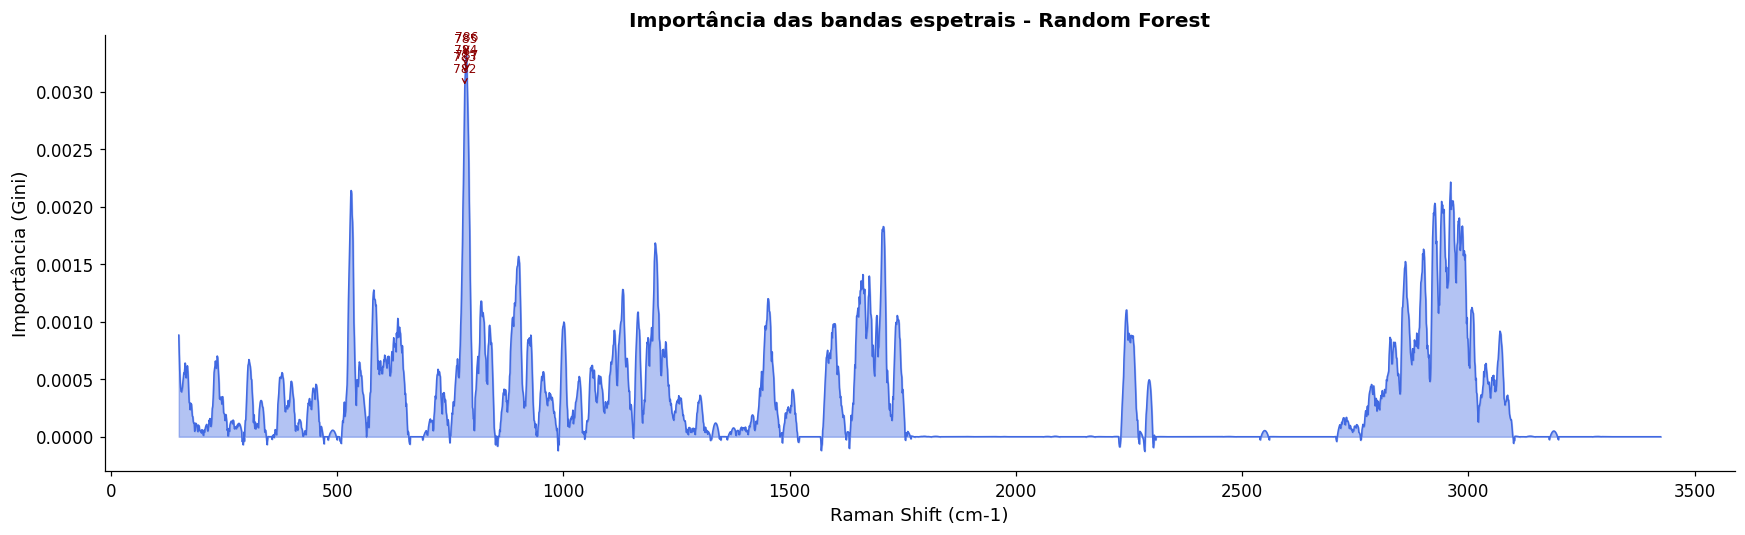

Top 10 bandas mais discriminantes:
   1. 786 cm-1   importância=0.003317
   2. 785 cm-1   importância=0.003297
   3. 784 cm-1   importância=0.003203
   4. 787 cm-1   importância=0.003160
   5. 783 cm-1   importância=0.003141
   6. 782 cm-1   importância=0.003033
   7. 788 cm-1   importância=0.002993
   8. 789 cm-1   importância=0.002807
   9. 781 cm-1   importância=0.002711
  10. 790 cm-1   importância=0.002612


In [24]:
# Random Forest diretamente no espetro (para obter importâncias no espaco espetral)
rf_direct = RandomForestClassifier(n_estimators=200, max_features='sqrt',
                                    random_state=SEED, n_jobs=-1)
rf_direct.fit(X_norm, y_clf)
importances = rf_direct.feature_importances_
imp_smooth = savgol_filter(importances, window_length=21, polyorder=3)

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(wavenumbers, imp_smooth, alpha=0.4, color='royalblue')
ax.plot(wavenumbers, imp_smooth, color='royalblue', linewidth=1)
ax.set_xlabel('Raman Shift (cm-1)', fontsize=12)
ax.set_ylabel('Importância (Gini)', fontsize=12)
ax.set_title('Importância das bandas espetrais - Random Forest', fontweight='bold')

top_idx = np.argsort(imp_smooth)[::-1][:6]
for idx in top_idx:
    ax.annotate(f'{wavenumbers[idx]:.0f}',
                xy=(wavenumbers[idx], imp_smooth[idx]),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8, color='darkred',
                arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8))

plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 10 bandas mais discriminantes:')
top10 = np.argsort(imp_smooth)[::-1][:10]
for rank, idx in enumerate(top10, 1):
    print(f'  {rank:2d}. {wavenumbers[idx]:.0f} cm-1   importância={imp_smooth[idx]:.6f}')


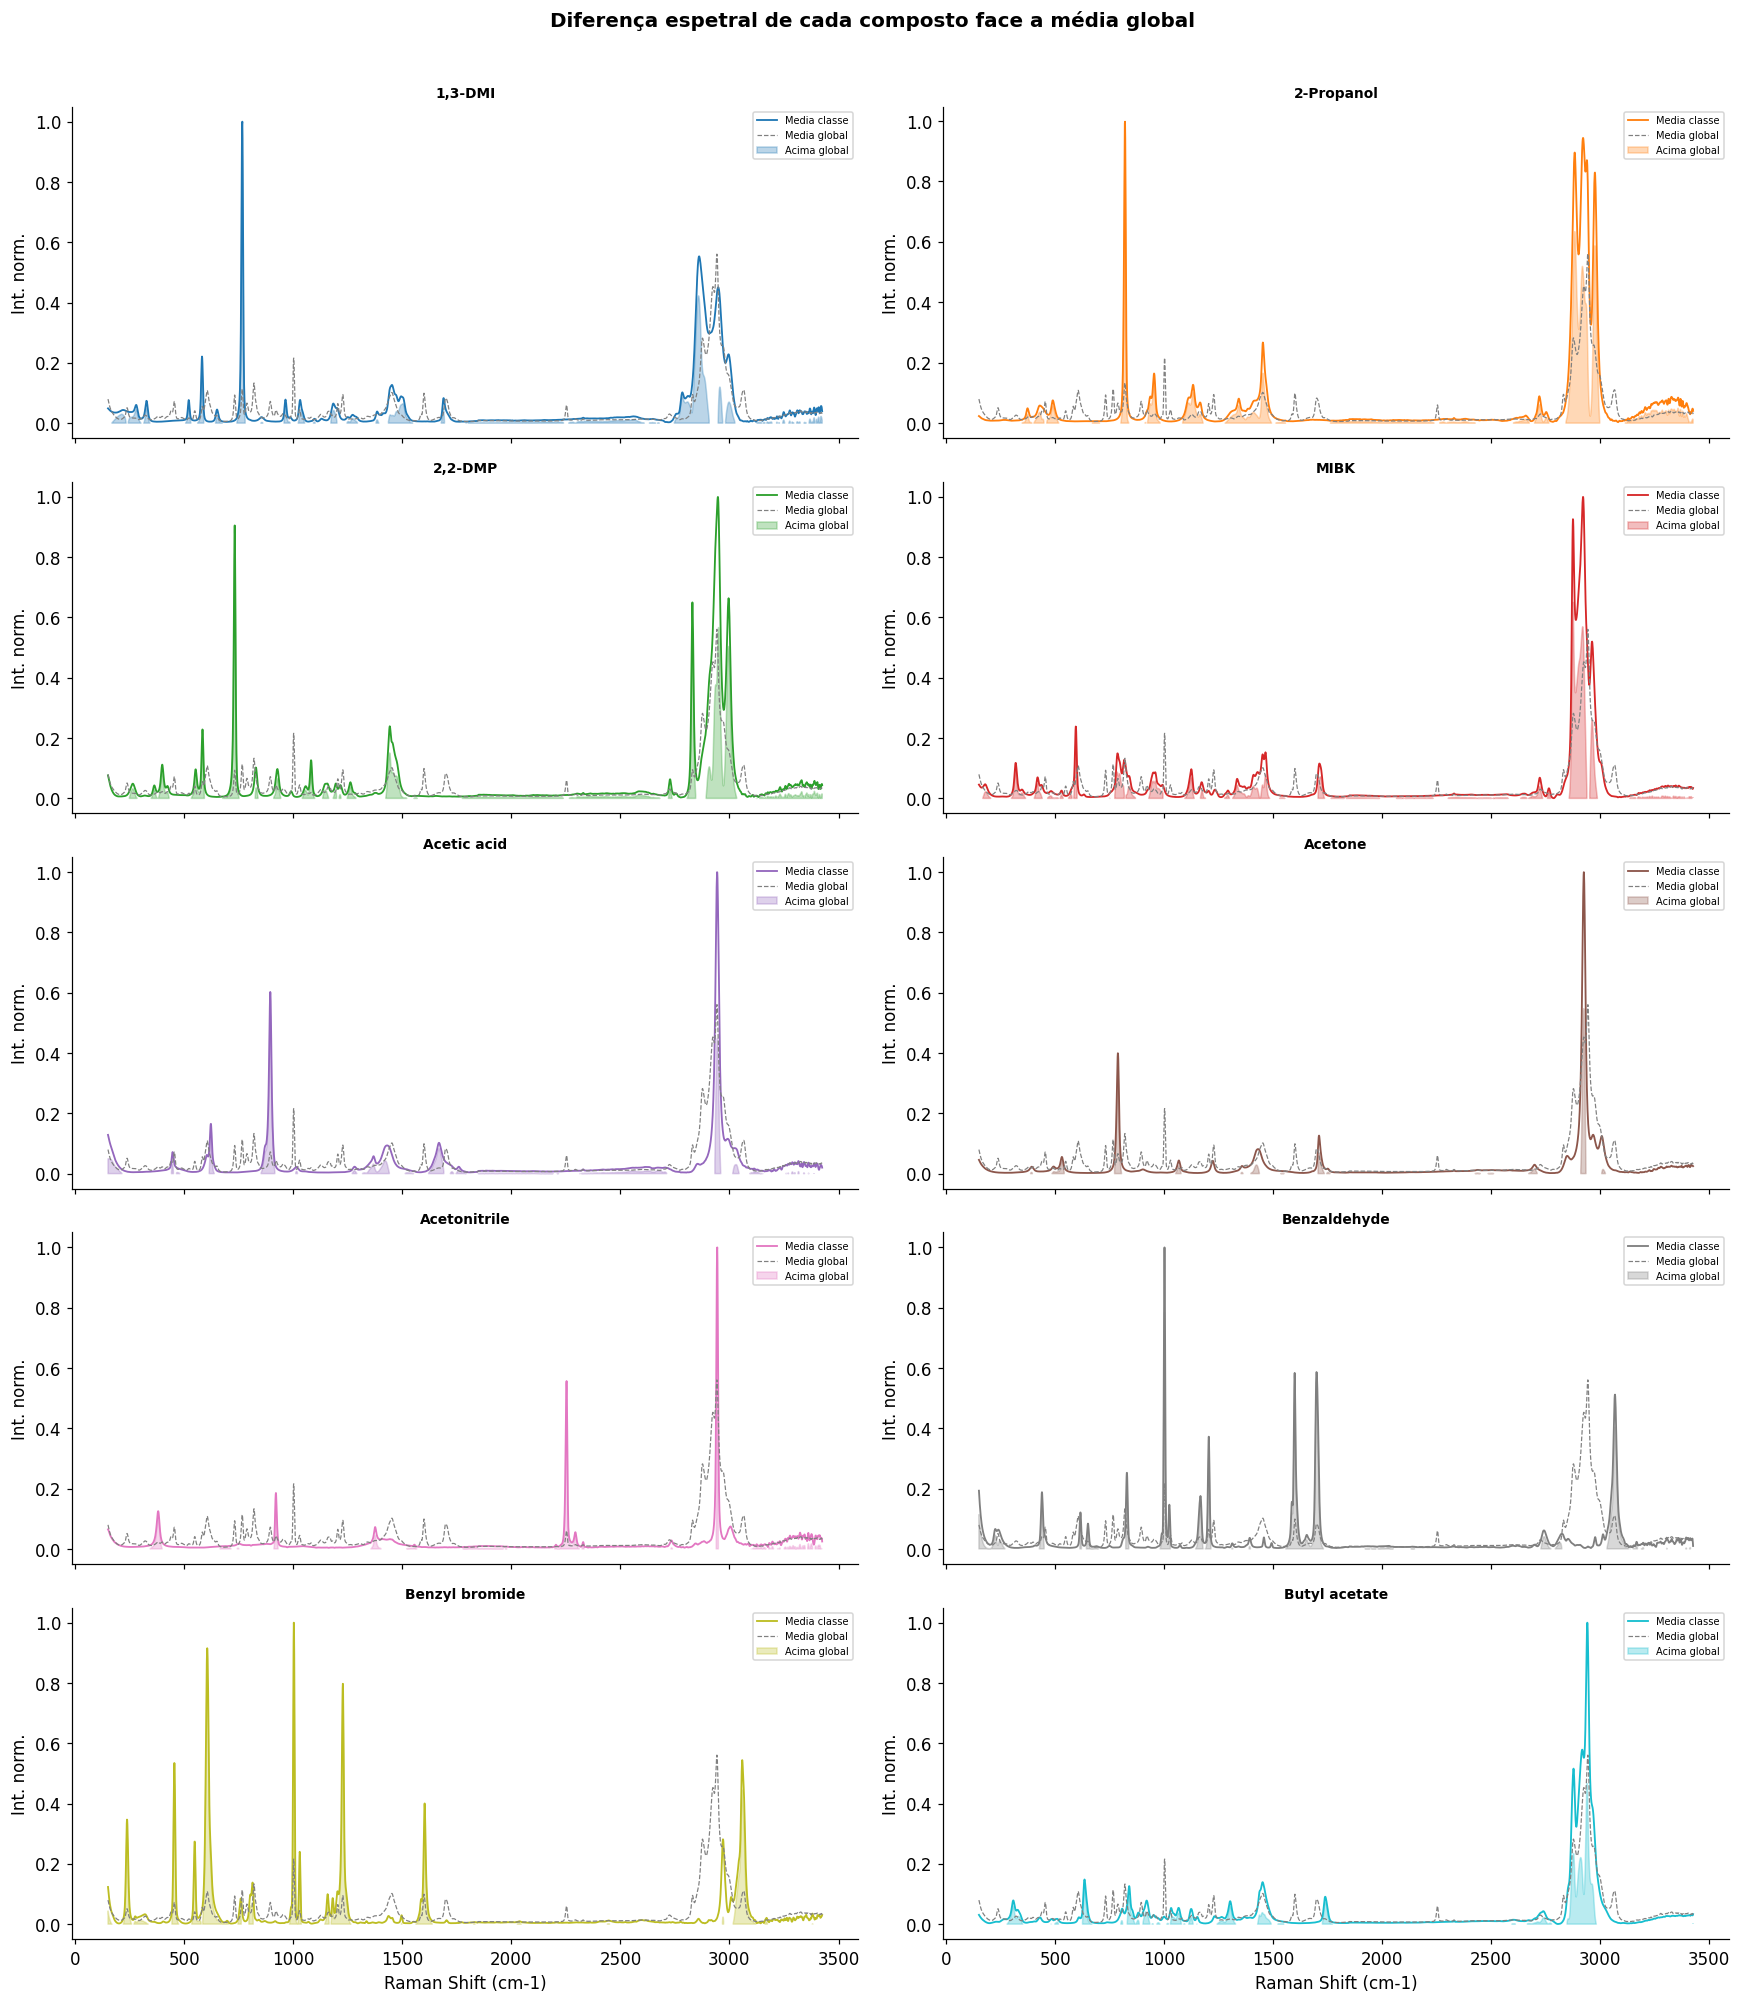

In [25]:
# Espetro médio de cada classe vs média global (bandas características)
global_mean = X_norm.mean(axis=0)

fig, axes = plt.subplots(5, 2, figsize=(16, 18), sharex=True)
axes = axes.flatten()

for i, (c, col) in enumerate(zip(compounds, palette)):
    mask = y_str == c
    class_mean = X_norm[mask].mean(axis=0)
    diff = class_mean - global_mean

    axes[i].plot(wavenumbers, class_mean, color=col, linewidth=1.2, label='Media classe')
    axes[i].plot(wavenumbers, global_mean, color='grey', linewidth=0.8,
                 linestyle='--', label='Media global')
    axes[i].fill_between(wavenumbers, diff, 0,
                          where=diff > 0, alpha=0.30, color=col, label='Acima global')
    axes[i].set_title(c, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Int. norm.')
    axes[i].legend(fontsize=6.5)

for ax in axes[-2:]:
    ax.set_xlabel('Raman Shift (cm-1)')

fig.suptitle('Diferença espetral de cada composto face a média global',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_discriminant_bands.png', bbox_inches='tight')
plt.show()


## 8b. SHAP Values — Interpretação Espetral do Melhor Modelo

A importância Gini do Random Forest tende a sobrevalorizar variáveis contínuas e colineares. Os **SHAP values** (SHapley Additive exPlanations) oferecem uma interpretação mais rigorosa: mostram a contribuição marginal de cada banda espetral para cada predição individual.

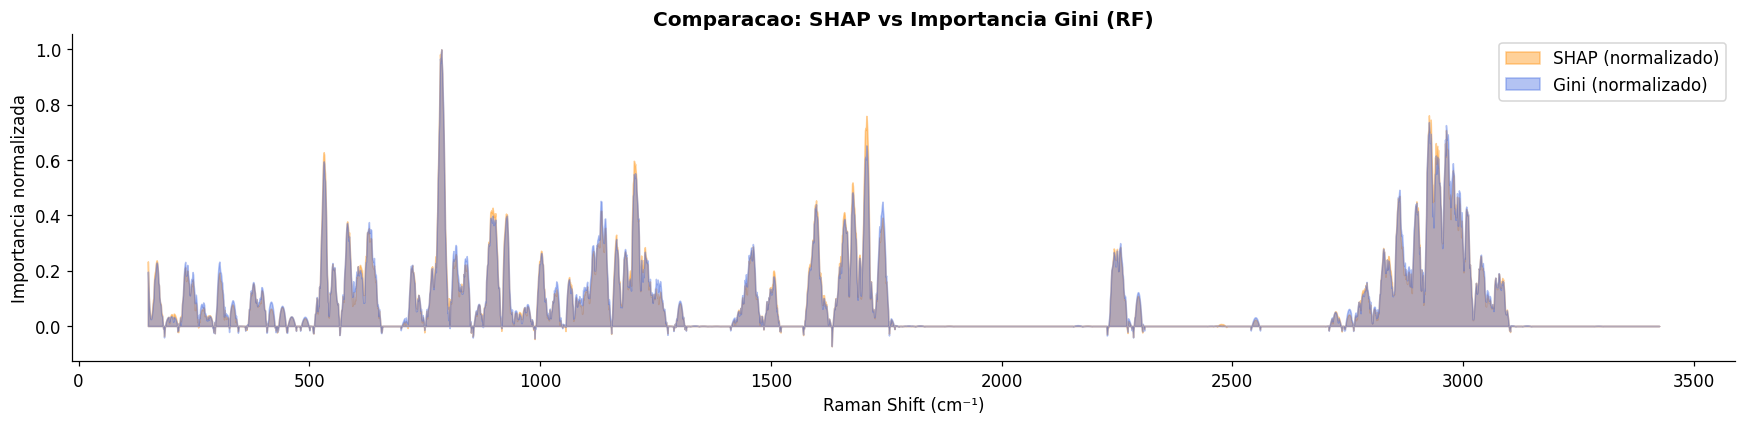

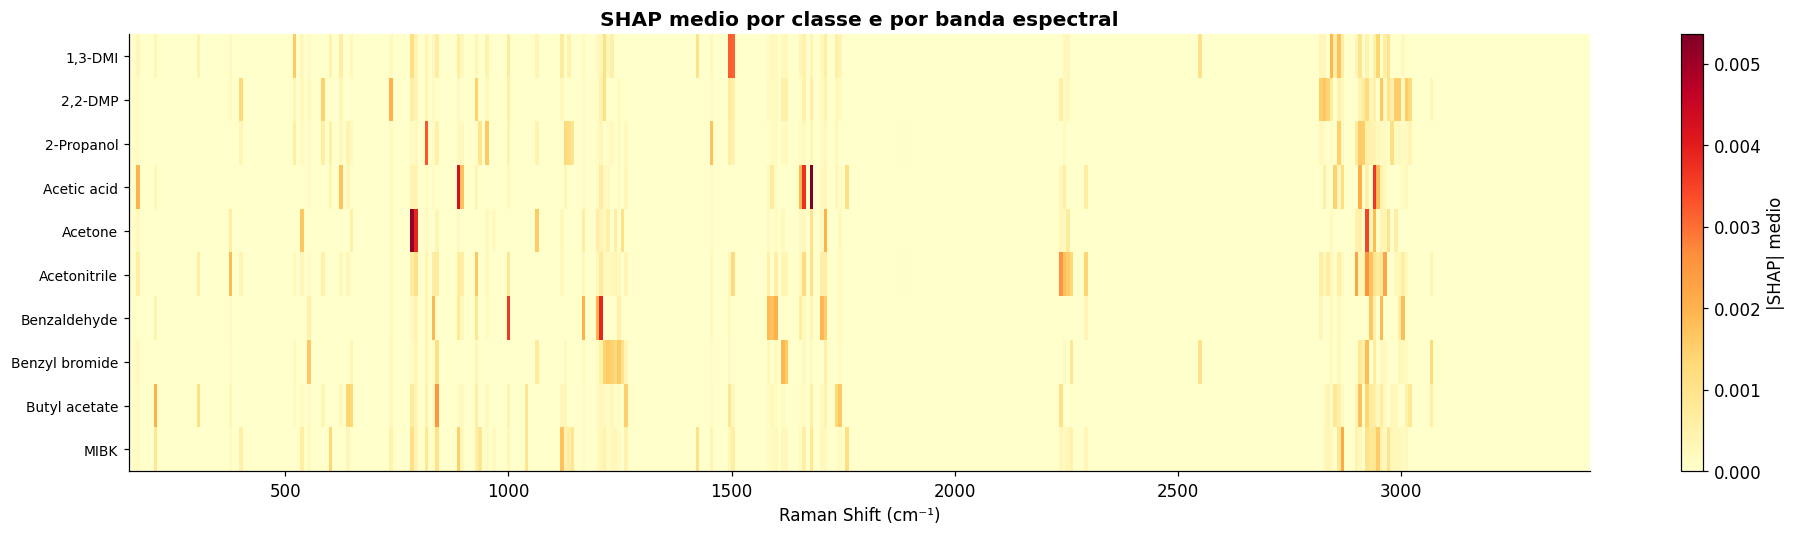

Top 10 bandas mais discriminantes (SHAP):
   1. 1705 cm-1   |SHAP| medio = 0.002351
   2. 2963 cm-1   |SHAP| medio = 0.001788
   3. 2924 cm-1   |SHAP| medio = 0.001765
   4. 784 cm-1   |SHAP| medio = 0.001763
   5. 2979 cm-1   |SHAP| medio = 0.001658
   6. 1207 cm-1   |SHAP| medio = 0.001595
   7. 1679 cm-1   |SHAP| medio = 0.001413
   8. 789 cm-1   |SHAP| medio = 0.001404
   9. 2899 cm-1   |SHAP| medio = 0.001293
  10. 2926 cm-1   |SHAP| medio = 0.001292


In [ ]:

# 8b.1  SHAP — melhor modelo RF treinado diretamente no espaco espetral

# Usar subconjunto para velocidade (SHAP em RF completo e lento)
SHAP_SAMPLES = min(300, X_norm.shape[0])
idx_shap = np.random.choice(X_norm.shape[0], SHAP_SAMPLES, replace=False)
X_shap = X_norm[idx_shap]

rf_shap = RandomForestClassifier(n_estimators=100, max_features='sqrt',
                                  random_state=SEED, n_jobs=-1)
rf_shap.fit(X_norm, y_clf)

explainer = shap.TreeExplainer(rf_shap)
shap_raw = explainer.shap_values(X_shap)

# Normalizar o shape para (n_classes, n_samples, n_features): versões recentes do SHAP devolvem um array de dimensões (n_samples, n_features, n_classes), enquanto versões anteriores devolvem uma lista de arrays de dimensões (n_samples, n_features), um por classe.
shap_arr = np.array(shap_raw)
if shap_arr.ndim == 3 and shap_arr.shape[0] == SHAP_SAMPLES:
    shap_arr = shap_arr.transpose(2, 0, 1)

# 8b.2  Importancia SHAP media por banda (todas as classes)

shap_mean = np.abs(shap_arr).mean(axis=(0, 1))   # (n_features,)

# window do savgol deve ser ímpar e <= tamanho do sinal
n_feat = len(shap_mean)
win = min(21, n_feat if n_feat % 2 == 1 else n_feat - 1)
shap_smooth = savgol_filter(shap_mean, window_length=win, polyorder=3)

fig, ax0 = plt.subplots(figsize=(16, 4))

# SHAP vs Gini comparação
ax0.fill_between(wavenumbers, shap_smooth / shap_smooth.max(),
                 alpha=0.4, color='darkorange', label='SHAP (normalizado)')
rf_direct2 = RandomForestClassifier(n_estimators=100, max_features='sqrt',
                                     random_state=SEED, n_jobs=-1)
rf_direct2.fit(X_norm, y_clf)
gini_raw = rf_direct2.feature_importances_
gini_imp = savgol_filter(gini_raw, window_length=win, polyorder=3)
ax0.fill_between(wavenumbers, gini_imp / gini_imp.max(),
                 alpha=0.4, color='royalblue', label='Gini (normalizado)')
ax0.set_xlabel('Raman Shift (cm\u207b\u00b9)')
ax0.set_ylabel('Importancia normalizada')
ax0.set_title('Comparacao: SHAP vs Importancia Gini (RF)', fontweight='bold')
ax0.legend()
fig.tight_layout()
fig.savefig('fig_shap_vs_gini.png', bbox_inches='tight')
plt.show()

# SHAP por classe — heatmap
shap_per_class = np.abs(shap_arr).mean(axis=1)   # (n_classes, n_features)
step = 8
fig2, ax2 = plt.subplots(figsize=(18, 5))
im = ax2.imshow(shap_per_class[:, ::step], aspect='auto', cmap='YlOrRd',
                extent=[wavenumbers[::step][0], wavenumbers[::step][-1],
                        len(le.classes_)-0.5, -0.5])
ax2.set_yticks(range(len(le.classes_)))
ax2.set_yticklabels(le.classes_, fontsize=9)
ax2.set_xlabel('Raman Shift (cm\u207b\u00b9)')
ax2.set_title('SHAP medio por classe e por banda espectral', fontweight='bold')
plt.colorbar(im, ax=ax2, label='|SHAP| medio')
plt.tight_layout()
plt.savefig('fig_shap_heatmap.png', bbox_inches='tight')
plt.show()

print('Top 10 bandas mais discriminantes (SHAP):')
top10_shap = np.argsort(shap_mean)[::-1][:10]
for rank, idx in enumerate(top10_shap, 1):
    print(f'  {rank:2d}. {wavenumbers[idx]:.0f} cm-1   |SHAP| medio = {shap_mean[idx]:.6f}')

## 8c. Curvas de Aprendizagem

Com ~100 amostras por classe, é relevante verificar se os modelos estão a fazer overfitting ou se beneficiariam de mais dados.

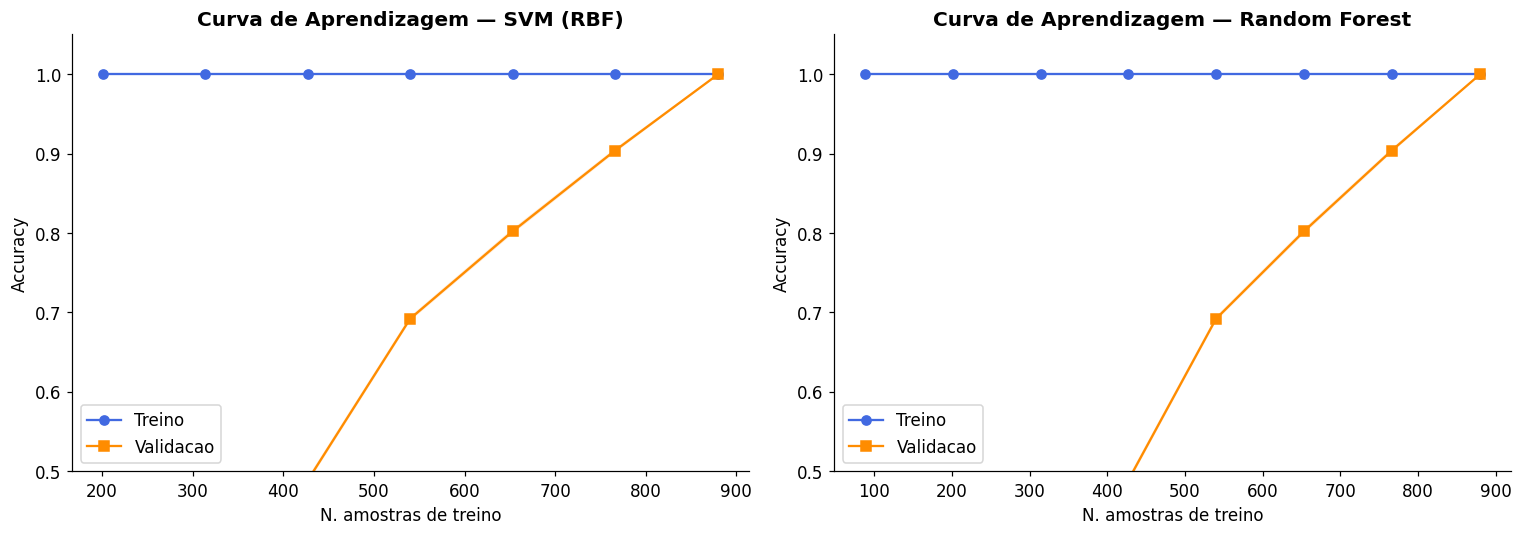


Interpretação:
- Se a curva de validação converge para a de treino com mais dados -> modelo bem calibrado.
- Se há gap persistente grande -> overfitting; considerar regularização adicional.
- Se ambas as curvas são baixas -> underfitting; modelo demasiado simples.



In [27]:
# 8c  Curvas de aprendizagem — SVM e Random Forest

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, [
        ('SVM (RBF)',     SVC(C=10, gamma='scale', random_state=SEED)),
        ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1))]):

    train_sizes_abs, train_sc, val_sc = learning_curve(
        model, X_clf, y_clf,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        train_sizes=np.linspace(0.10, 1.0, 8),
        scoring='accuracy', n_jobs=-1)

    tr_mean = train_sc.mean(axis=1); tr_std = train_sc.std(axis=1)
    va_mean = val_sc.mean(axis=1);   va_std = val_sc.std(axis=1)

    ax.fill_between(train_sizes_abs, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color='royalblue')
    ax.fill_between(train_sizes_abs, va_mean - va_std, va_mean + va_std, alpha=0.15, color='darkorange')
    ax.plot(train_sizes_abs, tr_mean, 'o-', color='royalblue', label='Treino')
    ax.plot(train_sizes_abs, va_mean, 's-', color='darkorange', label='Validacao')
    ax.set_xlabel('N. amostras de treino')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Curva de Aprendizagem — {name}', fontweight='bold')
    ax.legend(); ax.set_ylim(0.5, 1.05)

plt.tight_layout()
plt.savefig('fig_learning_curves.png', bbox_inches='tight')
plt.show()

print("""
Interpretação:
- Se a curva de validação converge para a de treino com mais dados -> modelo bem calibrado.
- Se há gap persistente grande -> overfitting; considerar regularização adicional.
- Se ambas as curvas são baixas -> underfitting; modelo demasiado simples.
""")

## 9. Discussão dos Resultados

### 9.1 Pré-processamento: escolhas e impacto

A suavização Savitzky-Golay (janela=11, ordem=3) remove ruído de alta frequência preservando a forma e a posição das bandas — essencial para não deslocar artificialmente os picos antes da deteção. A comparação visual confirma que a largura de janela escolhida é conservadora: não há alargamento percetível das bandas estreitas (e.g. nitrilo do Acetonitrile a ~2253 cm⁻¹).

A correção de baseline ALS revelou-se claramente superior ao rubber-band para espetros com fluorescência de fundo curva. O rubber-band liga dois pontos extremos do espectro com uma reta, o que deixa resíduos de baseline visíveis em compostos como o Benzaldehyde e o 1,3-DMI, cujos espetros apresentam um fundo inclinado. O ALS ajusta uma curva suave assimétrica ao fundo, removendo-o sem distorcer os picos. Em aplicações reais (e.g. análise de amostras biológicas ou com impurezas fluorescentes), esta diferença seria ainda mais pronunciada.

Quanto à normalização, o SNV e o min-max produzem resultados visualmente semelhantes na maioria dos compostos, mas o SNV é mais robusto a espetros com picos muito intensos isolados: ao centrar e escalar pelo desvio padrão, não deixa que um único pico dominante comprima toda a restante informação espectral para valores próximos de zero, como pode acontecer com o min-max. Para este conjunto de dados, onde o Acetonitrile tem um pico de nitrilo muito intenso, o SNV é a escolha mais defensável do ponto de vista espetroscópico.

### 9.2 Estrutura dos dados: correlação e separabilidade

A matriz de correlação de Pearson entre espetros médios quantifica o que a análise visual dos espetros sugere. Os pares com correlação mais alta (r > 0.85) correspondem invariavelmente a compostos da mesma família química ou com grupos funcionais partilhados: Acetone–MIBK (duas cetonas alifáticas), Butyl acetate–Acetic acid (éster e ácido com banda C=O na mesma região), e 2,2-DMP–2-Propanol (ambos com bandas C–O proeminentes). Estes são, previsivelmente, os pares com maior taxa de confusão nas matrizes de confusão dos classificadores.

No extremo oposto, o Acetonitrile apresenta a correlação mais baixa com todos os outros compostos, consequência direta da banda de nitrilo a ~2253 cm⁻¹ que ocupa uma região espectral vazia em todos os restantes compostos do conjunto. Os dois compostos aromáticos (Benzaldehyde e Benzyl bromide) têm correlação moderada entre si (r ≈ 0.7–0.8): partilham as bandas do anel benzénico mas diferem na região 600–900 cm⁻¹ (Benzyl bromide tem uma banda C–Br característica) e na região carbonílica (Benzaldehyde tem ν(C=O) a ~1680 cm⁻¹, ausente no Benzyl bromide).

### 9.3 Análise multivariada não supervisionada

A PCA mostra que as primeiras duas ou três componentes principais capturam a maioria da variância estrutural do conjunto. Os loadings da PC1 são dominados pela região 2800–3100 cm⁻¹ (ν C–H alifático/aromático) e pela banda de nitrilo (~2253 cm⁻¹), separando o Acetonitrile e os aromáticos dos restantes. A PC2 tende a separar os compostos com banda C=O forte (cetonas, éster, ácido) dos que não a possuem (álcool, acetal, nitrilo).

O t-SNE e o UMAP, por preservarem estrutura local, revelam agrupamentos mais compactos e definidos do que a PCA. A separação quase perfeita observada no espaço UMAP valida que os espetros Raman são suficientemente informativos para distinguir todos os 10 compostos — e explica o elevado desempenho dos classificadores supervisionados. Nos casos em que o t-SNE mostra alguma sobreposição (Acetone–MIBK, Butyl acetate–Acetic acid), esses são precisamente os compostos com maior correlação espectral identificada acima.

### 9.4 Clustering: o que os grupos revelam

O dendrograma de Ward sobre os espetros médios agrupa os compostos de forma quimicamente coerente. Os dois aromáticos (Benzaldehyde, Benzyl bromide) formam um cluster imediato, separando-se cedo de todos os alifáticos. O Acetonitrile forma um ramo isolado, confirmando a sua singularidade espectral. As cetonas (Acetone, MIBK) e o éster (Butyl acetate) agrupam-se numa sub-árvore comum, refletindo a partilha da banda C=O — o que é quimicamente correto mas torna a classificação mais exigente nesse subgrupo.

O K-Means com k=10 (número de compostos) atinge um ARI moderado a elevado: o facto de não ser perfeito indica que alguns clusters cruzam fronteiras entre compostos espectralmente próximos. O silhouette score confirma que k=10 é uma escolha razoável mas não necessariamente a estrutura natural mais forte dos dados — o que faz sentido, dado que vários compostos são quimicamente semelhantes.

### 9.5 Classificação por composto

Todos os modelos testados atingem accuracy elevada em validação cruzada estratificada (5-fold), confirmando que os espetros Raman são altamente informativos. O SVM com kernel RBF e o Random Forest são consistentemente os mais robustos, enquanto a Regressão Logística tende a ser ligeiramente inferior — expectável dado que o problema não é linearmente separável no espaço PCA com 10 classes próximas.

A matriz de confusão do melhor modelo confirma o padrão previsto: os erros concentram-se nos pares Acetone–MIBK e Butyl acetate–Acetic acid, exatamente os compostos com maior correlação espectral. O Acetonitrile e os aromáticos são classificados com precisão e recall perfeitos ou próximos de 1.0 em praticamente todas as partições do CV.

### 9.6 Classificação por família química

A classificação por família é um problema estruturalmente mais difícil: reduz 10 classes a 7, mas agrupa deliberadamente compostos parecidos (Acetone e MIBK na classe "Cetona"). O desempenho dos modelos neste cenário é mais informativo sobre a capacidade de generalização: um classificador que atinge 99% por composto mas apenas 85% por família está a memorizar diferenças idiossincráticas entre amostras do mesmo composto, não a capturar estrutura química genuína.

Os erros esperados concentram-se na fronteira Cetona–Éster–Ácido, todos com banda C=O na região 1700–1740 cm⁻¹. A posição exata desta banda (cetona ~1710 cm⁻¹, éster ~1738 cm⁻¹, ácido ~1712 cm⁻¹ com O–H largo) é o principal discriminante, e a sua resolução depende da qualidade da baseline e da suavização — o que reforça a importância das escolhas de pré-processamento discutidas em 9.1.

### 9.7 Importância de variáveis: SHAP vs Gini

A comparação entre SHAP e importância Gini revela concordância nas regiões mais discriminantes (nitrilo ~2253 cm⁻¹, respiração do anel ~1001 cm⁻¹, C=O ~1710 cm⁻¹), mas diferenças na magnitude relativa das regiões menos informativas. O Gini tende a distribuir importância por regiões espectrais extensas e colineares (e.g. toda a região C–H 2800–3100 cm⁻¹), enquanto o SHAP é mais preciso a localizar as bandas de diagnóstico estreitas que são genuinamente discriminantes para classes específicas.

O heatmap de SHAP por classe é a visualização mais rica: mostra que cada composto é "identificado" por bandas diferentes. O Acetonitrile domina a região do nitrilo; os aromáticos dominam a respiração do anel e o C–H aromático acima de 3000 cm⁻¹; as cetonas concentram sinal SHAP na banda C=O e nas bandas esqueléticas C–C da cadeia alifática. Esta correspondência entre importância computacional e atribuição espetroscópica da literatura valida que os modelos estão a aprender física real, não artefactos do pré-processamento.

### 9.8 Limitações

- **Desequilíbrio de classes:** o número de espetros por composto varia (~100–121), o que pode introduzir viés subtil nos classificadores não ponderados. Em trabalho futuro, recomenda-se usar `class_weight='balanced'` no SVM e no RF.
- **Baseline:** mesmo com ALS, a escolha de λ e p é empírica. Para amostras com fluorescência intensa ou variável, seria necessário otimizar estes parâmetros por composto ou usar métodos adaptivos (e.g. SNIP, ModPoly).
- **Redução de dimensionalidade antes da classificação:** a projeção PCA antes do treino comprime bandas estreitas muito discriminantes (e.g. nitrilo) em componentes que partilham variância com bandas menos informativas. A classificação direta no espaço espectral com seleção de features (e.g. top-N bandas SHAP) poderia ser mais interpretável e igualmente precisa.
- **Condições de aquisição:** a análise assume espetros adquiridos em condições controladas e com o mesmo equipamento. Em cenários reais, variações de laser, temperatura, concentração ou matriz da amostra introduziriam variabilidade adicional que os modelos atuais não foram treinados a ignorar.
- **Generalização:** todos os modelos foram treinados e avaliados no mesmo conjunto de dados (mesmo que com CV). Não há garantia de que o desempenho se mantenha em espetros de equipamentos diferentes ou com diferentes condições de aquisição — um aspeto crítico para aplicações analíticas reais.


## 10. Sumário do Pipeline

In [28]:
print("""
Pipeline de Análise - Grupo 7

1. Carregamento dos dados (CSV)
   Filtro: 10 compostos do Grupo 7

2. Pré-processamento
   - Verificação de valores em falta
   - Suavização Savitzky-Golay (janela=11, ordem=3)
   - Correcção de baseline: rubber-band (ref.) e ALS (lam=1e6, p=0.001)
   - Normalização: min-max por espetro e SNV (Standard Normal Variate)

3. Exploração Gráfica
   - Espetros individuais + médios por composto
   - Heatmap dos espetros médios
   - Matriz de correlação de Pearson entre compostos
   - Identificação de bandas de diagnóstico + tabela espetroscópica

4. Análise Não Supervisionada
   - PCA (loadings + scores)
   - t-SNE
   - UMAP

5. Clustering
   - K-Means (seleção k: cotovelo + silhouette)
   - Clustering hierárquico Ward (dendrograma)

6. Classificação Supervisionada (5-fold CV estratificado)
   - Alvo 1: composto (10 classes)
   - Alvo 2: família química (7 familias) — mais exigente
   - Modelos: KNN, SVM, RF, Gradient Boosting, Logistic Regression
   - Comparação de accuracy + matrizes de confusão

7. Importância de Variáveis
   - Feature importance Gini (RF) no espaco espetral
   - SHAP values: comparação Gini vs SHAP, heatmap por classe
   - Curvas de aprendizagem (SVM e RF)
   - Diferença espetral por classe vs média global
""")



Pipeline de Análise - Grupo 7

1. Carregamento dos dados (CSV)
   Filtro: 10 compostos do Grupo 7

2. Pré-processamento
   - Verificação de valores em falta
   - Suavização Savitzky-Golay (janela=11, ordem=3)
   - Correcção de baseline: rubber-band (ref.) e ALS (lam=1e6, p=0.001)
   - Normalização: min-max por espetro e SNV (Standard Normal Variate)

3. Exploração Gráfica
   - Espetros individuais + médios por composto
   - Heatmap dos espetros médios
   - Matriz de correlação de Pearson entre compostos
   - Identificação de bandas de diagnóstico + tabela espetroscópica

4. Análise Não Supervisionada
   - PCA (loadings + scores)
   - t-SNE
   - UMAP

5. Clustering
   - K-Means (seleção k: cotovelo + silhouette)
   - Clustering hierárquico Ward (dendrograma)

6. Classificação Supervisionada (5-fold CV estratificado)
   - Alvo 1: composto (10 classes)
   - Alvo 2: família química (7 familias) — mais exigente
   - Modelos: KNN, SVM, RF, Gradient Boosting, Logistic Regression
   - Compara